# Project Overview

This project implements a CNN-based pipeline for a Dog Identification App, tackling two core tasks:  
1. **Detection:** Determine whether an image contains a human, a dog, or neither.  
2. **Classification:** If it’s a dog, predict the breed among 133 possible classes.

**Background & Motivation:**  
- Dog breed identification can power photo-tagging apps, shelter intake systems, and veterinary triage tools.  
- We leverage two public datasets:
  - **Stanford Dog Dataset:** 8,345 total dog images across 133 breeds  
    - 6,675 training / 835 validation / 835 test  
  - **Labeled Faces in the Wild (LFW):** 13,233 human images for human-face detection

**Human Detection Approach:**  
- We use OpenCV’s Haar feature–based cascade classifier (pre-trained XML in `haarcascades/`) to detect faces.  
- **Note:** This requires a clear frontal face; later we’ll discuss whether this is a reasonable user expectation and explore alternatives (e.g., deep-learning–based person detectors).

**Preprocessing:**  
- All images are resized to 224×224 and normalized to match ResNet-50’s input requirements.  
- Dog images are loaded per-breed; human images feed the face detector.

**Goal:**  
- Deliver a final function `detect_and_classify(img_path)` that returns `{'human' | 'dog' | 'neither'}` and, for dogs, the top-3 predicted breeds.

In [1]:
import tensorflow as tf

# Set memory growth BEFORE importing or using anything from Keras backend
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

from tensorflow.keras import backend as K
import gc

#  Clear old graphs
def clear_graph():
    K.clear_session()
    gc.collect()

clear_graph()

2025-04-30 21:40:45.672654: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-30 21:40:45.672707: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-30 21:40:45.672755: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-30 21:40:45.683080: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-30 21:40:48.623312: I tensorflow/compiler/

In [40]:
# # Install the necessary package
# # Restart the kernel once after install this package
!python3 -m pip install opencv-python-headless==4.9.0.80

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for opencv-python-headless==4.9.0.80 from https://files.pythonhosted.org/packages/71/19/3c65483a80a1d062d46ae20faf5404712d25cb1dfdcaf371efbd67c38544/opencv_python_headless-4.9.0.80-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 25.8 MB/s eta 0:00:00:00:0100:01

[notice] A new release of pip is available: 23.2.1 -> 25.1
[notice] To update, run: python3 -m pip install --upgrade pip


# Data Scientist Nanodegree

## Convolutional Neural Networks

## Project: Write an Algorithm for a Dog Identification App 


This notebook walks you through one of the most popular Udacity projects across machine learning and artificial intellegence nanodegree programs.  The goal is to classify images of dogs according to their breed.  

If you are looking for a more guided capstone project related to deep learning and convolutional neural networks, this might be just it.  Notice that even if you follow the notebook to creating your classifier, you must still create a blog post or deploy an application to fulfill the requirements of the capstone project.

Also notice, you may be able to use only parts of this notebook (for example certain coding portions or the data) without completing all parts and still meet all requirements of the capstone project.

---

In this notebook, some template code has already been provided for you, and you will need to implement additional functionality to successfully complete this project. You will not need to modify the included code beyond what is requested. Sections that begin with **'(IMPLEMENTATION)'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section, and the specifics of the implementation are marked in the code block with a 'TODO' statement. Please be sure to read the instructions carefully! 

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.

>**Note:** Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut.  Markdown cells can be edited by double-clicking the cell to enter edit mode.

The rubric contains _optional_ "Stand Out Suggestions" for enhancing the project beyond the minimum requirements. If you decide to pursue the "Stand Out Suggestions", you should include the code in this IPython notebook.



---
### Why We're Here 

In this notebook, you will make the first steps towards developing an algorithm that could be used as part of a mobile or web app.  At the end of this project, your code will accept any user-supplied image as input.  If a dog is detected in the image, it will provide an estimate of the dog's breed.  If a human is detected, it will provide an estimate of the dog breed that is most resembling.  The image below displays potential sample output of your finished project (... but we expect that each student's algorithm will behave differently!). 

![Sample Dog Output](images/sample_dog_output.png)

In this real-world setting, you will need to piece together a series of models to perform different tasks; for instance, the algorithm that detects humans in an image will be different from the CNN that infers dog breed.  There are many points of possible failure, and no perfect algorithm exists.  Your imperfect solution will nonetheless create a fun user experience!

### The Road Ahead

We break the notebook into separate steps.  Feel free to use the links below to navigate the notebook.

* [Step 0](#step0): Import Datasets
* [Step 1](#step1): Detect Humans
* [Step 2](#step2): Detect Dogs
* [Step 3](#step3): Create a CNN to Classify Dog Breeds (from Scratch)
* [Step 4](#step4): Use a CNN to Classify Dog Breeds (using Transfer Learning)
* [Step 5](#step5): Create a CNN to Classify Dog Breeds (using Transfer Learning)
* [Step 6](#step6): Write your Algorithm
* [Step 7](#step7): Test Your Algorithm

---
<a id='step0'></a>
## Step 0: Import Datasets

### Import Dog Dataset

In the code cell below, we import a dataset of dog images.  We populate a few variables through the use of the `load_files` function from the scikit-learn library:
- `train_files`, `valid_files`, `test_files` - numpy arrays containing file paths to images
- `train_targets`, `valid_targets`, `test_targets` - numpy arrays containing onehot-encoded classification labels 
- `dog_names` - list of string-valued dog breed names for translating labels

In [2]:
# # Run the following cell only if the /workspace/home/dog-project/dog_images/ folder is not present in your workspace.
# # The cell below will copy the data to your /workspace directory. 
# !cp -rp /data/dog_images/ /workspace/home/dog-project

# '''
# NOTE
# There is a known "Permission denied" issue with copying the following files. You can ignore them.
# - Ibizan_hound_05697.jpg
# - American_foxhound_00503.jpg
# - Basset_hound_01064.jpg
# - Labrador_retriever_06476.jpg
# - Manchester_terrier_06806.jpg
# - Norwegian_lundehund_07217.jpg
# '''

In [5]:
from sklearn.datasets import load_files       
from keras.utils import to_categorical
import numpy as np
from glob import glob

# Define function to load train, test, and validation datasets
def load_dataset(path):
    data = load_files(path)
    dog_files = data['filenames']
    dog_targets = to_categorical(np.array(data['target']), 133)
    return dog_files, dog_targets

# Load train, test, and validation datasets
train_files, train_targets = load_dataset('/workspace/home/dog-project/dog_images/train')
valid_files, valid_targets = load_dataset('/workspace/home/dog-project/dog_images/valid')
test_files, test_targets = load_dataset('/workspace/home/dog-project/dog_images/test')

# Load list of dog names
dog_names = [item[20:-1] for item in sorted(glob("/workspace/home/dog-project/dog_images/train/*/"))]

# Print statistics about the dataset
print(f'There are {len(dog_names)} total dog categories.')
print(f'There are {len(train_files) + len(valid_files) + len(test_files)} total dog images.')
print(f'There are {len(train_files)} training dog images.')
print(f'There are {len(valid_files)} validation dog images.')
print(f'There are {len(test_files)} test dog images.')

There are 133 total dog categories.
There are 8345 total dog images.
There are 6675 training dog images.
There are 835 validation dog images.
There are 835 test dog images.


Top 10 Most Frequent Dog Breeds:


,breed,count
0,005.Alaskan_malamute,77
1,029.Border_collie,74
2,015.Basset_hound,72
3,057.Dalmatian,71
4,014.Basenji,69
5,041.Bullmastiff,69
6,039.Bull_terrier,69
7,046.Cavalier_king_charles_spaniel,67
8,011.Australian_cattle_dog,66
9,087.Irish_terrier,66


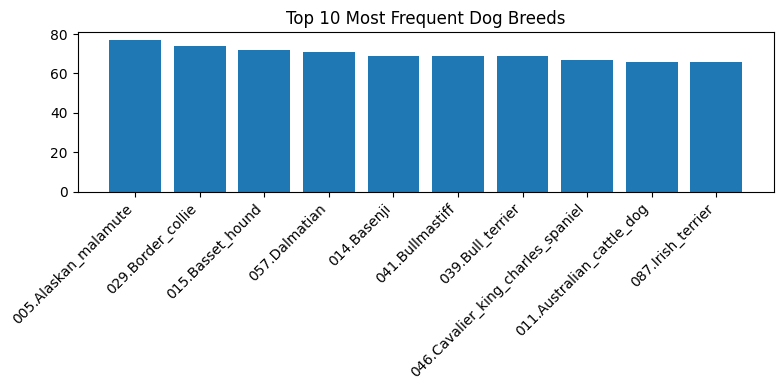


Top 10 Least Frequent Dog Breeds:


,breed,count
123,105.Neapolitan_mastiff,31
124,116.Parson_russell_terrier,30
125,126.Saint_bernard,30
126,128.Smooth_fox_terrier,30
127,131.Wirehaired_pointing_griffon,30
128,133.Yorkshire_terrier,30
129,121.Plott,28
130,102.Manchester_terrier,28
131,108.Norwegian_buhund,26
132,132.Xoloitzcuintli,26


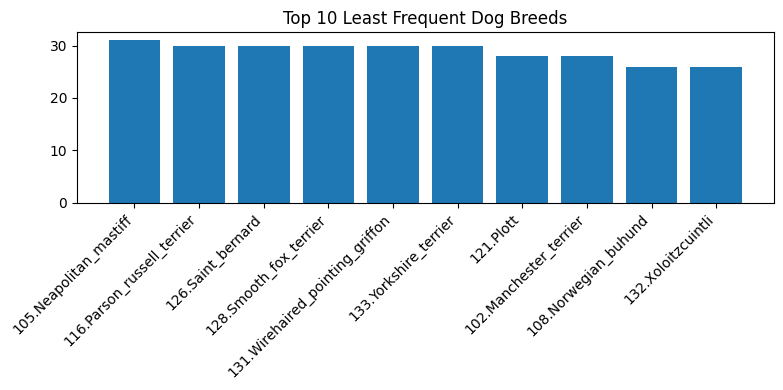

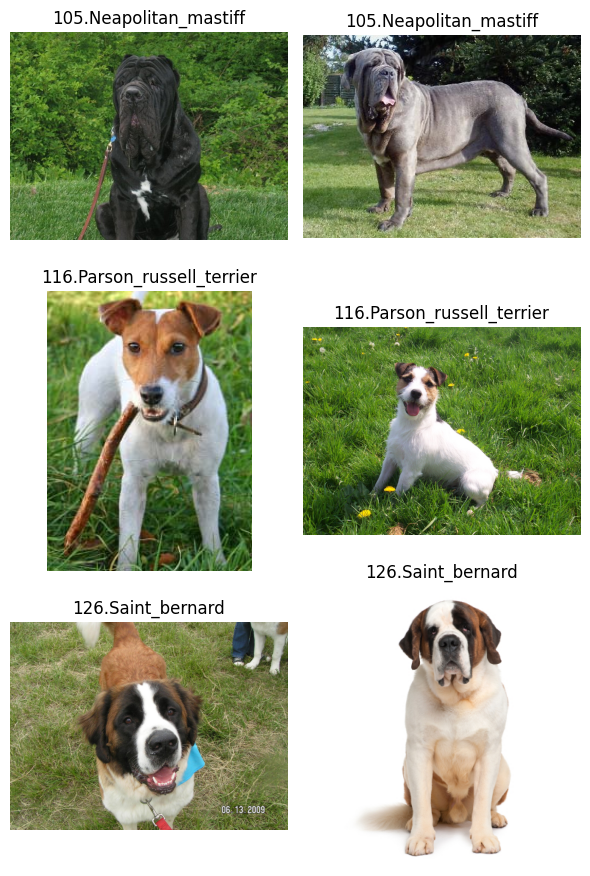

In [7]:
import os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Path to training images folder
train_folder = '/workspace/home/dog-project/dog_images/train' 

if not os.path.isdir(train_folder):
    print(f"Directory not found: {train_folder}\nPlease adjust the path to your training images folder.")
else:
    # Load train dataset
    data = load_files(train_folder)
    filenames = data['filenames']
    labels = data['target']
    breed_names = data['target_names']

    # Count images per breed
    label_counts = Counter(labels)
    counts_dict = {breed_names[i]: label_counts[i] for i in range(len(breed_names))}

    # Create a DataFrame for counts
    df_counts = pd.DataFrame(list(counts_dict.items()), columns=['breed', 'count'])
    df_counts_sorted = df_counts.sort_values('count', ascending=False).reset_index(drop=True)

    # Display top 10 and bottom 10 breeds by image count
    top10 = df_counts_sorted.head(10)
    bottom10 = df_counts_sorted.tail(10)

    print("Top 10 Most Frequent Dog Breeds:")
    display(top10)

    # Plotting distributions
    plt.figure(figsize=(8, 4))
    plt.bar(top10['breed'], top10['count'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Top 10 Most Frequent Dog Breeds')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 Least Frequent Dog Breeds:")
    display(bottom10)
    
    plt.figure(figsize=(8, 4))
    plt.bar(bottom10['breed'], bottom10['count'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Top 10 Least Frequent Dog Breeds')
    plt.tight_layout()
    plt.show()

    # Display sample images for bottom 3 under-represented breeds
    bottom3 = bottom10['breed'].tolist()[:3]
    samples_per_breed = 2

    plt.figure(figsize=(samples_per_breed * 3, len(bottom3) * 3))
    for i, breed in enumerate(bottom3):
        breed_paths = [f for f, lbl in zip(filenames, labels) if breed_names[lbl] == breed]
        selected = random.sample(breed_paths, min(samples_per_breed, len(breed_paths)))
        for j, img_path in enumerate(selected):
            img = mpimg.imread(img_path)
            ax = plt.subplot(len(bottom3), samples_per_breed, i*samples_per_breed + j + 1)
            ax.imshow(img)
            ax.set_title(breed)
            ax.axis('off')

    plt.tight_layout()
    plt.show()


### Import Human Dataset

In the code cell below, we import a dataset of human images, where the file paths are stored in the numpy array `human_files`.

In [7]:
import random
random.seed(8675309)

# Load filenames in shuffled human dataset
human_files = np.array(glob("../../../data/lfw/*/*"))
random.shuffle(human_files)

# Print statistics about the human dataset
print(f'There are {len(human_files)} total human images.')

There are 13233 total human images.


---
<a id='step1'></a>
## Step 1: Detect Humans

We use OpenCV's implementation of [Haar feature-based cascade classifiers](http://docs.opencv.org/trunk/d7/d8b/tutorial_py_face_detection.html) to detect human faces in images.  OpenCV provides many pre-trained face detectors, stored as XML files on [github](https://github.com/opencv/opencv/tree/master/data/haarcascades).  We have downloaded one of these detectors and stored it in the `haarcascades` directory.

In the next code cell, we demonstrate how to use this detector to find human faces in a sample image.

Number of faces detected: 1


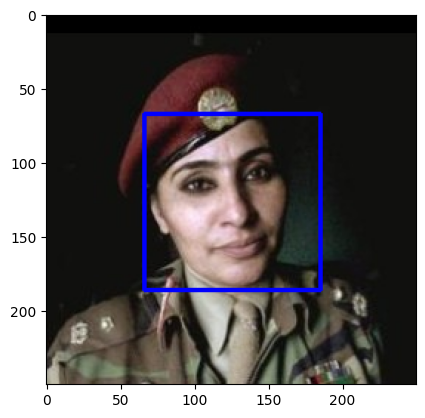

In [16]:
import cv2                
import matplotlib.pyplot as plt                        
%matplotlib inline                               

# extract pre-trained face detector
face_cascade = cv2.CascadeClassifier('haarcascades/haarcascade_frontalface_alt.xml')

# load color (BGR) image
img = cv2.imread(human_files[3])
# convert BGR image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# find faces in image
faces = face_cascade.detectMultiScale(gray)

# print number of faces detected in the image
print('Number of faces detected:', len(faces))

# get bounding box for each detected face
for (x,y,w,h) in faces:
    # add bounding box to color image
    cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    
# convert BGR image to RGB for plotting
cv_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# display the image, along with bounding box
plt.imshow(cv_rgb)
plt.show()

Before using any of the face detectors, it is standard procedure to convert the images to grayscale.  The `detectMultiScale` function executes the classifier stored in `face_cascade` and takes the grayscale image as a parameter.  

In the above code, `faces` is a numpy array of detected faces, where each row corresponds to a detected face.  Each detected face is a 1D array with four entries that specifies the bounding box of the detected face.  The first two entries in the array (extracted in the above code as `x` and `y`) specify the horizontal and vertical positions of the top left corner of the bounding box.  The last two entries in the array (extracted here as `w` and `h`) specify the width and height of the box.

### Write a Human Face Detector

We can use this procedure to write a function that returns `True` if a human face is detected in an image and `False` otherwise.  This function, aptly named `face_detector`, takes a string-valued file path to an image as input and appears in the code block below.

In [17]:
# returns "True" if face is detected in image stored at img_path
def face_detector(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray)
    return len(faces) > 0

### (IMPLEMENTATION) Assess the Human Face Detector

__Question 1:__ Use the code cell below to test the performance of the `face_detector` function.  
- What percentage of the first 100 images in `human_files` have a detected human face?  
- What percentage of the first 100 images in `dog_files` have a detected human face? 

Ideally, we would like 100% of human images with a detected face and 0% of dog images with a detected face.  You will see that our algorithm falls short of this goal, but still gives acceptable performance.  We extract the file paths for the first 100 images from each of the datasets and store them in the numpy arrays `human_files_short` and `dog_files_short`.

__Answer:__ 

In [15]:
human_files_short = human_files[:100]
dog_files_short = train_files[:100]
# Do NOT modify the code above this line.

## Test the performance of the face_detector algorithm 
## on the images in human_files_short and dog_files_short.
counter_human = 0
counter_dog = 0
for human, dog in zip(human_files_short, dog_files_short):
    if face_detector(human):
        counter_human += 1
    if face_detector(dog):
        counter_dog += 1
print(f"Number of deected faces in human images: {counter_human}")
print(f"Number of detected faces in dog images: {counter_dog}")

Number of deected faces in human images: 100
Number of detected faces in dog images: 12


__Question 2:__ This algorithmic choice necessitates that we communicate to the user that we accept human images only when they provide a clear view of a face (otherwise, we risk having unneccessarily frustrated users!). In your opinion, is this a reasonable expectation to pose on the user? If not, can you think of a way to detect humans in images that does not necessitate an image with a clearly presented face?

__Answer:__

We suggest the face detector from OpenCV as a potential way to detect human images in your algorithm, but you are free to explore other approaches, especially approaches that make use of deep learning :).  Please use the code cell below to design and test your own face detection algorithm.  If you decide to pursue this _optional_ task, report performance on each of the datasets.

In [6]:
## (Optional) Report the performance of another  
## face detection algorithm on the LFW dataset
### Feel free to use as many code cells as needed.

---
<a id='step2'></a>
## Step 2: Detect Dogs

In this section, we use a pre-trained [ResNet-50](http://ethereon.github.io/netscope/#/gist/db945b393d40bfa26006) model to detect dogs in images.  Our first line of code downloads the ResNet-50 model, along with weights that have been trained on [ImageNet](http://www.image-net.org/), a very large, very popular dataset used for image classification and other vision tasks.  ImageNet contains over 10 million URLs, each linking to an image containing an object from one of [1000 categories](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a).  Given an image, this pre-trained ResNet-50 model returns a prediction (derived from the available categories in ImageNet) for the object that is contained in the image.

In [59]:
from keras.applications.resnet50 import ResNet50

# define ResNet50 model
ResNet50_model = ResNet50(weights='imagenet')

102967424/102967424 [==============================] - 0s 0us/step


### Pre-process the Data

When using TensorFlow as backend, Keras CNNs require a 4D array (which we'll also refer to as a 4D tensor) as input, with shape

$$
(\text{nb_samples}, \text{rows}, \text{columns}, \text{channels}),
$$

where `nb_samples` corresponds to the total number of images (or samples), and `rows`, `columns`, and `channels` correspond to the number of rows, columns, and channels for each image, respectively.  

The `path_to_tensor` function below takes a string-valued file path to a color image as input and returns a 4D tensor suitable for supplying to a Keras CNN.  The function first loads the image and resizes it to a square image that is $224 \times 224$ pixels.  Next, the image is converted to an array, which is then resized to a 4D tensor.  In this case, since we are working with color images, each image has three channels.  Likewise, since we are processing a single image (or sample), the returned tensor will always have shape

$$
(1, 224, 224, 3).
$$

The `paths_to_tensor` function takes a numpy array of string-valued image paths as input and returns a 4D tensor with shape 

$$
(\text{nb_samples}, 224, 224, 3).
$$

Here, `nb_samples` is the number of samples, or number of images, in the supplied array of image paths.  It is best to think of `nb_samples` as the number of 3D tensors (where each 3D tensor corresponds to a different image) in your dataset!

In [32]:
from keras.preprocessing import image                  
from tqdm import tqdm

def path_to_tensor(img_path):
    try:
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        # Normalize the image tensor
        return np.expand_dims(x, axis=0) 
    except IOError:
        print(f"Warning: Skipping corrupted image {img_path}")
        return None

def paths_to_tensor(img_paths):
    batch_tensors = []
    for img_path in img_paths:
        tensor = path_to_tensor(img_path)
        if tensor is not None:
            batch_tensors.append(tensor[0])
    return np.array(batch_tensors)

### Making Predictions with ResNet-50

Getting the 4D tensor ready for ResNet-50, and for any other pre-trained model in Keras, requires some additional processing.  First, the RGB image is converted to BGR by reordering the channels.  All pre-trained models have the additional normalization step that the mean pixel (expressed in RGB as $[103.939, 116.779, 123.68]$ and calculated from all pixels in all images in ImageNet) must be subtracted from every pixel in each image.  This is implemented in the imported function `preprocess_input`.  If you're curious, you can check the code for `preprocess_input` [here](https://github.com/fchollet/keras/blob/master/keras/applications/imagenet_utils.py).

Now that we have a way to format our image for supplying to ResNet-50, we are now ready to use the model to extract the predictions.  This is accomplished with the `predict` method, which returns an array whose $i$-th entry is the model's predicted probability that the image belongs to the $i$-th ImageNet category.  This is implemented in the `ResNet50_predict_labels` function below.

By taking the argmax of the predicted probability vector, we obtain an integer corresponding to the model's predicted object class, which we can identify with an object category through the use of this [dictionary](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a). 

In [61]:
from keras.applications.resnet50 import preprocess_input, decode_predictions

def ResNet50_predict_labels(img_path):
    # returns prediction vector for image located at img_path
    img = preprocess_input(path_to_tensor(img_path))
    return np.argmax(ResNet50_model.predict(img))

### Write a Dog Detector

While looking at the [dictionary](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), you will notice that the categories corresponding to dogs appear in an uninterrupted sequence and correspond to dictionary keys 151-268, inclusive, to include all categories from `'Chihuahua'` to `'Mexican hairless'`.  Thus, in order to check to see if an image is predicted to contain a dog by the pre-trained ResNet-50 model, we need only check if the `ResNet50_predict_labels` function above returns a value between 151 and 268 (inclusive).

We use these ideas to complete the `dog_detector` function below, which returns `True` if a dog is detected in an image (and `False` if not).

In [62]:
### returns "True" if a dog is detected in the image stored at img_path
def dog_detector(img_path):
    prediction = ResNet50_predict_labels(img_path)
    return ((prediction <= 268) & (prediction >= 151)) 

In [63]:
ResNet50_predict_labels(dog_files_short[1])

1/1 [==============================] - 2s 2s/step


265

### (IMPLEMENTATION) Assess the Dog Detector

__Question 3:__ Use the code cell below to test the performance of your `dog_detector` function.  
- What percentage of the images in `human_files_short` have a detected dog?  
- What percentage of the images in `dog_files_short` have a detected dog?

__Answer:__ 

In [31]:
### Test the performance of the dog_detector function
### on the images in human_files_short and dog_files_short.

counter_human = 0
counter_dog = 0
for human, dog in zip(human_files_short, dog_files_short):
    if dog_detector(human):
        counter_human += 1
    if dog_detector(dog):
        counter_dog += 1
print(f"Number of detected dogs in human images: {counter_human}%")
print(f"Number of detected dogs in dog images: {counter_dog}%")

1/1 [==============================] - 0s 41ms/step
Number of detected dogs in human images: 0%
Number of detected dogs in dog images: 100%


---
<a id='step3'></a>
## Step 3: Create a CNN to Classify Dog Breeds (from Scratch)

Now that we have functions for detecting humans and dogs in images, we need a way to predict breed from images.  In this step, you will create a CNN that classifies dog breeds.  You must create your CNN _from scratch_ (so, you can't use transfer learning _yet_!), and you must attain a test accuracy of at least 1%.  In Step 5 of this notebook, you will have the opportunity to use transfer learning to create a CNN that attains greatly improved accuracy.

Be careful with adding too many trainable layers!  More parameters means longer training, which means you are more likely to need a GPU to accelerate the training process.  Thankfully, Keras provides a handy estimate of the time that each epoch is likely to take; you can extrapolate this estimate to figure out how long it will take for your algorithm to train. 

We mention that the task of assigning breed to dogs from images is considered exceptionally challenging.  To see why, consider that *even a human* would have great difficulty in distinguishing between a Brittany and a Welsh Springer Spaniel.  

Brittany | Welsh Springer Spaniel
- | - 
<img src="images/Brittany_02625.jpg" width="100"> | <img src="images/Welsh_springer_spaniel_08203.jpg" width="200">

It is not difficult to find other dog breed pairs with minimal inter-class variation (for instance, Curly-Coated Retrievers and American Water Spaniels).  

Curly-Coated Retriever | American Water Spaniel
- | -
<img src="images/Curly-coated_retriever_03896.jpg" width="200"> | <img src="images/American_water_spaniel_00648.jpg" width="200">


Likewise, recall that labradors come in yellow, chocolate, and black.  Your vision-based algorithm will have to conquer this high intra-class variation to determine how to classify all of these different shades as the same breed.  

Yellow Labrador | Chocolate Labrador | Black Labrador
- | -
<img src="images/Labrador_retriever_06457.jpg" width="150"> | <img src="images/Labrador_retriever_06455.jpg" width="240"> | <img src="images/Labrador_retriever_06449.jpg" width="220">

We also mention that random chance presents an exceptionally low bar: setting aside the fact that the classes are slightly imabalanced, a random guess will provide a correct answer roughly 1 in 133 times, which corresponds to an accuracy of less than 1%.  

Remember that the practice is far ahead of the theory in deep learning.  Experiment with many different architectures, and trust your intuition.  And, of course, have fun! 

### Pre-process the Data

We rescale the images by dividing every pixel in every image by 255.

In [39]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# === 1. Paths ===
train_dir = '/workspace/home/dog-project/dog_images/train'
valid_dir = '/workspace/home/dog-project/dog_images/valid'
test_dir  = '/workspace/home/dog-project/dog_images/test'

# === 2. ImageDataGenerator ===
datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32
target_size = (224, 224)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical'
)

valid_generator = datagen.flow_from_directory(
    valid_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 6675 images belonging to 133 classes.
Found 835 images belonging to 133 classes.
Found 835 images belonging to 133 classes.


### (IMPLEMENTATION) Model Architecture

Create a CNN to classify dog breed.  At the end of your code cell block, summarize the layers of your model by executing the line:
    
        model.summary()

We have imported some Python modules to get you started, but feel free to import as many modules as you need.  If you end up getting stuck, here's a hint that specifies a model that trains relatively fast on CPU and attains >1% test accuracy in 5 epochs:

![Sample CNN](images/sample_cnn.png)
           
__Question 4:__ Outline the steps you took to get to your final CNN architecture and your reasoning at each step.  If you chose to use the hinted architecture above, describe why you think that CNN architecture should work well for the image classification task.

__Answer:__ 

In [41]:
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.layers import Dropout, Flatten, Dense
from keras.models import Sequential

model = Sequential()

# First convolutional layer: 16 filters, 2x2 kernel, ReLU activation
# Learns low-level features like edges and textures
model.add(Conv2D(16, (2, 2), activation='relu', input_shape=(224, 224, 3), padding='valid'))

# First max pooling layer: reduces spatial dimensions and computation
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolutional layer: 32 filters, deeper feature extraction
model.add(Conv2D(32, (2, 2), activation='relu', padding='valid'))

# Second max pooling layer: further downsampling
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third convolutional layer: 64 filters, higher-level feature extraction
model.add(Conv2D(64, (2, 2), activation='relu', padding='valid'))

# Third max pooling layer: more aggressive spatial reduction
model.add(MaxPooling2D(pool_size=(2, 2)))

# Global average pooling: reduces each feature map to a single value
# Helps reduce overfitting compared to Flatten
model.add(GlobalAveragePooling2D())

# Output layer: 133 neurons for 133 dog breed classes with softmax activation
model.add(Dense(133, activation='softmax'))

# Print model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 223, 223, 16)      208       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 16)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 110, 110, 32)      2080      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 55, 55, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 54, 54, 64)        8256      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 27, 27, 64)        0

### Compile the Model

In [42]:
from keras.optimizers import Adam

# Set a smaller learning rate
adam = Adam(learning_rate=0.001)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

### (IMPLEMENTATION) Train the Model

Train your model in the code cell below.  Use model checkpointing to save the model that attains the best validation loss.

You are welcome to [augment the training data](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), but this is not a requirement. 

In [44]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau  

### specify the number of epochs that you would like to use to train the model.

epochs = 25

### Do NOT modify the code below this line.

# Add checkpoint to save the best model
checkpointer = ModelCheckpoint(filepath='saved_models/weights.best.from_scratch.hdf5',
                               verbose=1, save_best_only=True)

# ReduceLROnPlateau: This callback reduces the learning rate when a metric has stopped improving.
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5)

# Stop training early if validation loss doesn't improve for 7 epochs
earlystopper = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)  # restores best weights before overfitting

# Train the model
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_steps=valid_generator.samples // batch_size,
    epochs=25,
    callbacks=[checkpointer, reduce_lr, ], #earlystopper
    verbose=2
)

Epoch 1/25

Epoch 1: val_loss improved from inf to 4.85954, saving model to saved_models/weights.best.from_scratch.hdf5
208/208 - 59s - loss: 4.8715 - accuracy: 0.0102 - val_loss: 4.8595 - val_accuracy: 0.0120 - lr: 0.0010 - 59s/epoch - 284ms/step
Epoch 2/25

Epoch 2: val_loss improved from 4.85954 to 4.82417, saving model to saved_models/weights.best.from_scratch.hdf5
208/208 - 51s - loss: 4.8416 - accuracy: 0.0148 - val_loss: 4.8242 - val_accuracy: 0.0168 - lr: 0.0010 - 51s/epoch - 247ms/step
Epoch 3/25

Epoch 3: val_loss improved from 4.82417 to 4.79269, saving model to saved_models/weights.best.from_scratch.hdf5
208/208 - 37s - loss: 4.7912 - accuracy: 0.0182 - val_loss: 4.7927 - val_accuracy: 0.0168 - lr: 0.0010 - 37s/epoch - 179ms/step
Epoch 4/25

Epoch 4: val_loss improved from 4.79269 to 4.76531, saving model to saved_models/weights.best.from_scratch.hdf5
208/208 - 37s - loss: 4.7491 - accuracy: 0.0200 - val_loss: 4.7653 - val_accuracy: 0.0156 - lr: 0.0010 - 37s/epoch - 177ms/s

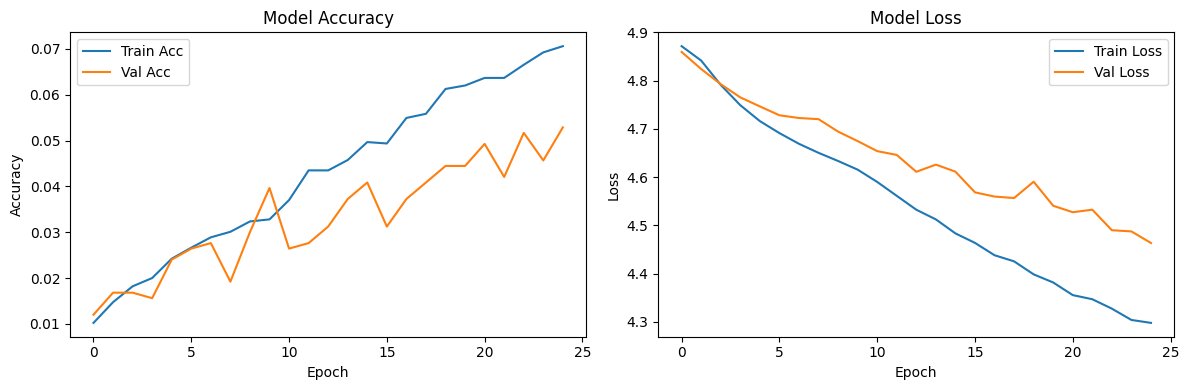

In [48]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Load the Model with the Best Validation Loss

In [45]:
model.load_weights('saved_models/weights.best.from_scratch.hdf5')

### Test the Model

Try out your model on the test dataset of dog images.  Ensure that your test accuracy is greater than 1%.

In [47]:
# Evaluate the model on the test data using `evaluate_generator`
test_loss, test_accuracy = model.evaluate(test_generator,
                                          steps=test_generator.samples // test_generator.batch_size,
                                          verbose=1)

print('Test accuracy: %.4f%%' % (test_accuracy * 100))

26/26 [==============================] - 4s 136ms/step - loss: 4.4578 - accuracy: 0.0577
Test accuracy: 5.7692%


---
<a id='step4'></a>
## Step 4: Use a CNN to Classify Dog Breeds

To reduce training time without sacrificing accuracy, we show you how to train a CNN using transfer learning.  In the following step, you will get a chance to use transfer learning to train your own CNN.

### Obtain Bottleneck Features

### Bottleneck Feature Extraction for Pretrained CNNs

To avoid mismatches between image files and labels (due to corrupted or missing images),
we use `ImageDataGenerator` with `shuffle=False` and extract **bottleneck features** directly from frozen CNNs like ResNet50, InceptionV3, VGG-19, or Xception.

This approach:
- Ensures consistent pairing of inputs and labels
- Speeds up training by precomputing convolutional features
- Saves features and one-hot targets to `.npy` or `.npz` files for reuse

We define a flexible pipeline that:
1. Uses the correct preprocessing for each pretrained model
2. Extracts features from train/valid/test folders
3. Bundles features and labels into compressed `.npz` files


In [2]:
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3, Xception, VGG19
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inception
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.vgg19 import preprocess_input as preprocess_vgg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

import numpy as np
import os
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Prevents crash on broken image files

# Mapping of model names to their base model + preprocess function
MODELS = {
    'Resnet50':  (ResNet50, preprocess_resnet),
    'InceptionV3': (InceptionV3, preprocess_inception),
    'Xception':  (Xception, preprocess_xception),
    'VGG19':     (VGG19, preprocess_vgg),
    'VGG16': (VGG16, preprocess_vgg16)

}

def extract_and_save_bottlenecks(model_name, output_dir='bottleneck_features',
                                 train_dir = '/workspace/home/dog-project/dog_images/train',
                                 valid_dir = '/workspace/home/dog-project/dog_images/valid',
                                 test_dir  = '/workspace/home/dog-project/dog_images/test',
                                 batch_size = 32
                                ):
    """Extract bottleneck features + labels for a given model."""
    print(f"\n🔄 Processing model: {model_name}")
    if model_name not in MODELS:
        raise ValueError(f"Unsupported model: {model_name}")

    base_class, preprocess_fn = MODELS[model_name]
    base_model = base_class(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    def _extract(gen_dir):
        gen = datagen.flow_from_directory(
            gen_dir, target_size=(224, 224),
            batch_size=batch_size, shuffle=False, class_mode='categorical'
        )
        steps = int(np.ceil(gen.samples / batch_size))
        features = base_model.predict(gen, steps=steps, verbose=1)
        labels = to_categorical(gen.classes, num_classes=133)
        return features, labels

    # Extract features and targets
    train_bf, train_targets = _extract(train_dir)
    valid_bf, valid_targets = _extract(valid_dir)
    test_bf,  test_targets  = _extract(test_dir)

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    # Save features
    np.savez_compressed(os.path.join(output_dir, f'Dog{model_name}Data.npz'),
                        train=train_bf, valid=valid_bf, test=test_bf)

    # Save targets
    np.savez_compressed(os.path.join(output_dir, f'Dog{model_name}Targets.npz'),
                        train=train_targets, valid=valid_targets, test=test_targets)

    print(f"✅ Saved features and targets for {model_name} to {output_dir}/")

In [18]:
import numpy as np

def load_bottleneck_and_targets(model_name, directory='bottleneck_features'):
    """Load precomputed bottleneck features and one-hot targets."""
    feat_file   = os.path.join(directory, f'Dog{model_name}Data.npz')
    target_file = os.path.join(directory, f'Dog{model_name}Targets.npz')

    if not (os.path.isfile(feat_file) and os.path.isfile(target_file)):
        raise FileNotFoundError(f"Missing {feat_file} or {target_file}")

    with np.load(feat_file) as f_data:
        train_X, valid_X, test_X = f_data['train'], f_data['valid'], f_data['test']
    with np.load(target_file) as t_data:
        train_y, valid_y, test_y = t_data['train'], t_data['valid'], t_data['test']

    assert train_X.shape[0] == train_y.shape[0], "Train features/labels mismatch"
    assert valid_X.shape[0] == valid_y.shape[0], "Valid features/labels mismatch"
    assert test_X.shape[0]  == test_y.shape[0],  "Test  features/labels mismatch"

    return train_X, valid_X, test_X, train_y, valid_y, test_y

In [13]:
for model_name in ['VGG16']:
    extract_and_save_bottlenecks(model_name)


🔄 Processing model: VGG16


2025-04-30 14:03:43.971825: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-30 14:03:43.984124: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-30 14:03:43.987379: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

58889256/58889256 [==============================] - 0s 0us/step
Found 6675 images belonging to 133 classes.


2025-04-30 14:03:46.976784: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600


209/209 [==============================] - 121s 559ms/step
Found 835 images belonging to 133 classes.
27/27 [==============================] - 13s 470ms/step
Found 835 images belonging to 133 classes.
27/27 [==============================] - 9s 352ms/step
✅ Saved features and targets for VGG16 to bottleneck_features/


In [19]:
# Load bottleneck features and targets for VGG16
train_VGG16, valid_VGG16, test_VGG16, vgg16_train_y, vgg16_valid_y, vgg16_test_y = load_bottleneck_and_targets('VGG16')

### Model Architecture

The model uses the the pre-trained VGG-16 model as a fixed feature extractor, where the last convolutional output of VGG-16 is fed as input to our model.  We only add a global average pooling layer and a fully connected layer, where the latter contains one node for each dog category and is equipped with a softmax.

In [22]:
VGG16_model = Sequential()
VGG16_model.add(GlobalAveragePooling2D(input_shape=train_VGG16.shape[1:]))
VGG16_model.add(Dense(133, activation='softmax'))

VGG16_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 133)               68229     
                                                                 
Total params: 68229 (266.52 KB)
Trainable params: 68229 (266.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Compile the Model

In [23]:
VGG16_model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

### Train the Model
**Modular Training with** `train_classifier()`

To simplify training on bottleneck features from multiple models (ResNet50, VGG16, etc.), we define a modular `train_classifier()` function. It handles dataset preparation, memory optimization, callbacks, and training.

We'll use this function in later steps to train classifiers on precomputed features from various CNN architectures efficiently.

In [24]:
import tensorflow as tf
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.layers import Dropout, Flatten, Dense, BatchNormalization, Activation
from keras.models import Sequential
from tensorflow.keras.models import load_model

def train_classifier(model, model_name, train_X, valid_X, train_y, valid_y, epochs=30, batch_size=32,
                     use_early_stop=False, save_dir='saved_models'):
    """
    Train a classifier on precomputed bottleneck features.

    Parameters
    ----------
    model : compiled Keras model
    model_name : str
        Name to use for saving the weights file.
    train_X, valid_X : np.ndarray
        Bottleneck features for training and validation sets.
    train_y, valid_y : np.ndarray
        One-hot encoded labels.
    epochs : int
        Number of epochs to train.
    batch_size : int
        Batch size for training.
    use_early_stop : bool
        Whether to apply early stopping.
    save_dir : str
        Directory to save model weights.
    """

    # Ensure save directory exists
    os.makedirs(save_dir, exist_ok=True)

    # Convert to float16 to reduce memory footprint
    train_X = train_X.astype('float16')
    valid_X = valid_X.astype('float16')

    # Prepare tf.data.Dataset pipelines
    train_ds = (tf.data.Dataset
                .from_tensor_slices((train_X, train_y))
                .shuffle(buffer_size=len(train_y), reshuffle_each_iteration=True)
#                 .cache()
                .batch(batch_size)
                .prefetch(1))

    valid_ds = (tf.data.Dataset
                .from_tensor_slices((valid_X, valid_y))
                .batch(batch_size)
                .prefetch(1))

    # Callbacks
    callbacks = [
        ModelCheckpoint(filepath=f'{save_dir}/weights.best.{model_name}.hdf5',
                        save_best_only=True, verbose=1)
    ]

    if use_early_stop:
        callbacks.append(EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1))

    # Train
    history = model.fit(train_ds,
                        validation_data=valid_ds,
                        epochs=epochs,
                        callbacks=callbacks,
                        verbose=1)
    return history


### Visualizing Training Progress with `plot_training_history()`

The `plot_training_history()` function provides a quick visualization of training and validation accuracy/loss across epochs. This helps monitor model performance and diagnose overfitting or underfitting during development.

We'll reuse this function for each model we train.

In [25]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_name='Model'):
    """
    Plot training & validation accuracy and loss from a Keras history object.

    Parameters
    ----------
    history : keras.callbacks.History
        History object returned by model.fit().
    model_name : str
        Used for titles and labels.
    """
    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [26]:
history = train_classifier(VGG16_model, 'VGG16', train_VGG16, valid_VGG16, vgg16_train_y, vgg16_valid_y)

Epoch 1/30


2025-05-01 00:20:30.384708: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7c3a400a6920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-01 00:20:30.384773: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2025-05-01 00:20:30.391491: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-01 00:20:30.515011: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


197/209 [===========================>..] - ETA: 0s - loss: 8.3488 - accuracy: 0.2015
Epoch 1: val_loss improved from inf to 4.13133, saving model to saved_models/weights.best.VGG16.hdf5
209/209 [==============================] - 2s 8ms/step - loss: 8.0759 - accuracy: 0.2135 - val_loss: 4.1313 - val_accuracy: 0.3653
Epoch 2/30
 19/209 [=>............................] - ETA: 1s - loss: 2.6429 - accuracy: 0.5132

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


195/209 [==========================>...] - ETA: 0s - loss: 2.3986 - accuracy: 0.5628
Epoch 2: val_loss improved from 4.13133 to 2.50850, saving model to saved_models/weights.best.VGG16.hdf5
209/209 [==============================] - 1s 7ms/step - loss: 2.3622 - accuracy: 0.5717 - val_loss: 2.5085 - val_accuracy: 0.5557
Epoch 3/30
204/209 [============================>.] - ETA: 0s - loss: 1.2864 - accuracy: 0.7253
Epoch 3: val_loss improved from 2.50850 to 2.17241, saving model to saved_models/weights.best.VGG16.hdf5
209/209 [==============================] - 1s 7ms/step - loss: 1.2790 - accuracy: 0.7261 - val_loss: 2.1724 - val_accuracy: 0.6168
Epoch 4/30
199/209 [===========================>..] - ETA: 0s - loss: 0.8003 - accuracy: 0.8072
Epoch 4: val_loss improved from 2.17241 to 2.04289, saving model to saved_models/weights.best.VGG16.hdf5
209/209 [==============================] - 1s 7ms/step - loss: 0.7986 - accuracy: 0.8058 - val_loss: 2.0429 - val_accuracy: 0.6539
Epoch 5/30
209/

208/209 [============================>.] - ETA: 0s - loss: 0.0074 - accuracy: 0.9982
Epoch 30: val_loss did not improve from 1.72405
209/209 [==============================] - 1s 6ms/step - loss: 0.0074 - accuracy: 0.9982 - val_loss: 1.8174 - val_accuracy: 0.7629


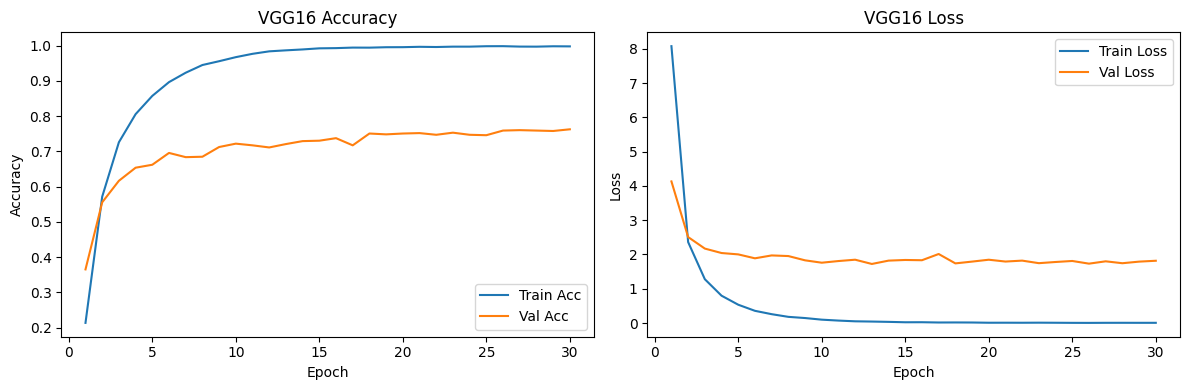

In [27]:
plot_training_history(history, model_name='VGG16')

### Load the Model with the Best Validation Loss

In [28]:
VGG16_model.load_weights('saved_models/weights.best.VGG16.hdf5')

### Test the Model

Now, we can use the CNN to test how well it identifies breed within our test dataset of dog images.  We print the test accuracy below.

In [29]:
# Test the model
test_predictions = VGG16_model.predict(test_VGG16, batch_size=20)
test_accuracy = 100 * np.mean(np.argmax(test_predictions, axis=1) == np.argmax(vgg16_test_y, axis=1))
print('Test accuracy: %.4f%%' % test_accuracy)

42/42 [==============================] - 0s 4ms/step
Test accuracy: 70.8982%


### Predict Dog Breed with the Model

In [31]:
from extract_bottleneck_features import *

def VGG16_predict_breed(img_path):
    # extract bottleneck features
    bottleneck_feature = extract_VGG16(path_to_tensor(img_path))
    # obtain predicted vector
    predicted_vector = VGG16_model.predict(bottleneck_feature)
    # return dog breed that is predicted by the model
    return dog_names[np.argmax(predicted_vector)]

### Visual Check of Model Predictions using `show_sample_predictions_from_test()`

To quickly check how well a model performs, I created a helper function called `show_sample_predictions_from_test()`. It randomly selects a few images from the test set and displays them with their actual and predicted dog breeds.

Since I plan to test multiple models (like VGG16, ResNet50, etc.), I made this function modular so I can reuse it easily with any prediction function. This helps me visually compare how different models perform without rewriting code each time.


In [8]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from glob import glob

# Load list of dog names
dog_names = [item[20:-1] for item in sorted(glob("/workspace/home/dog-project/dog_images/train/*/"))]

def show_sample_predictions_from_test(test_dir, predict_func, model_name='Model', sample_size=3):
    """
    Randomly selects images from the test directory and displays predictions.

    Parameters
    ----------
    test_dir : str
        Path to the test image directory (structured with subfolders for each breed).
    predict_func : callable
        Function that takes an image path and returns predicted breed name.
    model_name : str
        Name of the model to display in the plot title.
    sample_size : int
        Number of test images to display.
    """
    
    # Collect all image paths
    test_files = [os.path.join(dirpath, fname)
                  for dirpath, _, filenames in os.walk(test_dir)
                  for fname in filenames if fname.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Randomly select images
    sample_paths = random.sample(test_files, sample_size)

    # Display predictions
    plt.figure(figsize=(5 * sample_size, 5))
    for i, img_path in enumerate(sample_paths):
        img = image.load_img(img_path, target_size=(224, 224))
        actual_breed = os.path.basename(os.path.dirname(img_path))
        pred = predict_func(img_path)
        breed_file = pred.split("/")[-1]
        pred_breed = breed_file.split(".")[-1]

        plt.subplot(1, sample_size, i + 1)
        plt.imshow(img)
        plt.title(f'Actual: {actual_breed}\nPredicted: {pred_breed}', fontsize=10)
        plt.axis('off')

    plt.suptitle(f"{model_name} Sample Predictions", fontsize=14)
    plt.tight_layout()
    plt.show()

1/1 [==============================] - 0s 24ms/step


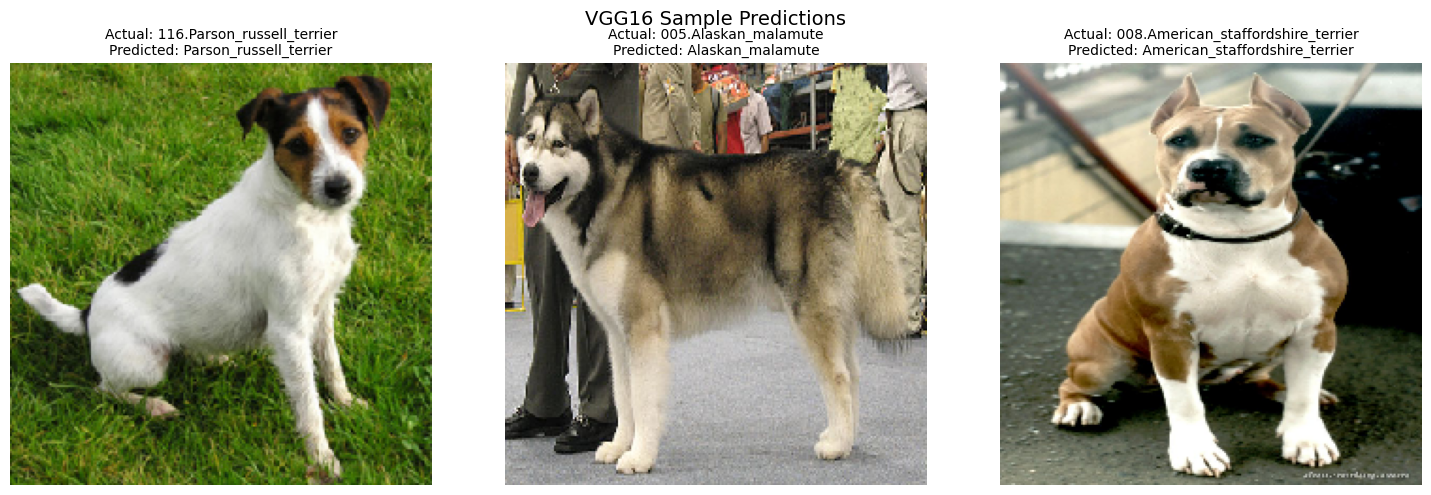

In [49]:
show_sample_predictions_from_test(
    test_dir='/workspace/home/dog-project/dog_images/test',
    predict_func=VGG16_predict_breed,
    model_name='VGG16'
)

---
<a id='step5'></a>
## Step 5: Create a CNN to Classify Dog Breeds (using Transfer Learning)

You will now use transfer learning to create a CNN that can identify dog breed from images.  Your CNN must attain at least 60% accuracy on the test set.

In Step 4, we used transfer learning to create a CNN using VGG-16 bottleneck features.  In this section, you must use the bottleneck features from a different pre-trained model.  To make things easier for you, we have pre-computed the features for all of the networks that are currently available in Keras:
- [VGG-19](https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/DogVGG19Data.npz) bottleneck features
- [ResNet-50](https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/DogResnet50Data.npz) bottleneck features
- [Inception](https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/DogInceptionV3Data.npz) bottleneck features
- [Xception](https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/DogXceptionData.npz) bottleneck features

The files are encoded as such:

    Dog{network}Data.npz
    
where `{network}`, in the above filename, can be one of `VGG19`, `Resnet50`, `InceptionV3`, or `Xception`.  Pick one of the above architectures, download the corresponding bottleneck features, and store the downloaded file in the `bottleneck_features/` folder in the repository.

### (IMPLEMENTATION) Obtain Bottleneck Features

In the code block below, extract the bottleneck features corresponding to the train, test, and validation sets by running the following:

    bottleneck_features = np.load('bottleneck_features/Dog{network}Data.npz')
    train_{network} = bottleneck_features['train']
    valid_{network} = bottleneck_features['valid']
    test_{network} = bottleneck_features['test']

In [38]:
# import urllib.request
# url = "https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/DogXceptionData.npz"
# bname = url.split(sep="/")[-1]
# save_path = f"bottleneck_features/{bname}"
# urllib.request.urlretrieve(url, save_path)

### Replacing Downloaded Bottleneck Features with Locally Extracted Ones

While the project provides precomputed bottleneck features for models like Xception, using these files led to shape and label mismatches with the current local dataset due to missing or unreadable images.

To resolve this issue, we chose to extract bottleneck features locally using the modular functions defined earlier. This ensures that the extracted features perfectly align with the images and labels in our dataset, allowing for consistent and error-free model training and evaluation.

In [9]:
for model_name in ['Resnet50', 'InceptionV3', 'Xception', 'VGG19']:
    extract_and_save_bottlenecks(model_name)


🔄 Processing model: Resnet50


2025-04-30 14:55:18.054683: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-30 14:55:18.067408: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-30 14:55:18.070694: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

94765736/94765736 [==============================] - 1s 0us/step
Found 6675 images belonging to 133 classes.


2025-04-30 14:55:23.497871: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600


209/209 [==============================] - 124s 581ms/step


2025-04-30 14:57:26.365604: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2679398400 exceeds 10% of free system memory.


Found 835 images belonging to 133 classes.
27/27 [==============================] - 13s 495ms/step
Found 835 images belonging to 133 classes.
27/27 [==============================] - 10s 387ms/step
✅ Saved features and targets for Resnet50 to bottleneck_features/

🔄 Processing model: InceptionV3
87910968/87910968 [==============================] - 0s 0us/step
Found 6675 images belonging to 133 classes.
209/209 [==============================] - 47s 211ms/step
Found 835 images belonging to 133 classes.
27/27 [==============================] - 5s 171ms/step
Found 835 images belonging to 133 classes.
27/27 [==============================] - 4s 142ms/step
✅ Saved features and targets for InceptionV3 to bottleneck_features/

🔄 Processing model: Xception
83683744/83683744 [==============================] - 0s 0us/step
Found 6675 images belonging to 133 classes.
209/209 [==============================] - 38s 166ms/step


2025-04-30 15:02:28.154411: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2679398400 exceeds 10% of free system memory.


Found 835 images belonging to 133 classes.
27/27 [==============================] - 13s 487ms/step
Found 835 images belonging to 133 classes.
27/27 [==============================] - 5s 179ms/step
✅ Saved features and targets for Xception to bottleneck_features/

🔄 Processing model: VGG19
80134624/80134624 [==============================] - 0s 0us/step
Found 6675 images belonging to 133 classes.
209/209 [==============================] - 130s 599ms/step
Found 835 images belonging to 133 classes.
27/27 [==============================] - 6s 220ms/step
Found 835 images belonging to 133 classes.
27/27 [==============================] - 10s 376ms/step
✅ Saved features and targets for VGG19 to bottleneck_features/


### Step 4: Transfer Learning (Bottleneck Features Only)

In this step, we keep the pretrained convolutional base frozen and train only a small “head” on top of the bottleneck features. This lets us see how much performance we gain by re-using ResNet50’s learned filters without any further tuning.

#### 4.1 Load Bottleneck Features

We assume you have already saved your bottleneck features as NumPy arrays:
- `train_bf` / `valid_bf` / `test_bf`  (shape: `[n_samples, 7, 7, 2048]`)  
- `train_targets` / `valid_targets` / `test_targets` (one-hot labels)

In [4]:
# Load bottleneck features and targets for ResNet50
train_Resnet50 , valid_Resnet50, test_Resnet50, resnet50_train_y, resnet50_valid_y, resnet50_test_y = \
    load_bottleneck_and_targets('Resnet50')

### (IMPLEMENTATION) Model Architecture

Create a CNN to classify dog breed.  At the end of your code cell block, summarize the layers of your model by executing the line:
    
        <your model's name>.summary()
   
__Question 5:__ Outline the steps you took to get to your final CNN architecture and your reasoning at each step.  Describe why you think the architecture is suitable for the current problem.

__Answer:__ 



In [21]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.layers import Dropout, Flatten, Dense, BatchNormalization, Activation
from keras.models import Sequential
from tensorflow.keras.models import load_model

In [6]:
### Define your architecture.
Resnet50_model = Sequential()
Resnet50_model.add(GlobalAveragePooling2D(input_shape=train_Resnet50.shape[1:]))
Resnet50_model.add(Dense(133, activation='softmax'))

Resnet50_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 133)               272517    
                                                                 
Total params: 272517 (1.04 MB)
Trainable params: 272517 (1.04 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2025-04-30 18:42:57.264641: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-30 18:42:57.269557: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-30 18:42:57.272718: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

### (IMPLEMENTATION) Compile the Model

In [7]:
### Compile the model.
Resnet50_model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

### (IMPLEMENTATION) Train the Model

Train your model in the code cell below.  Use model checkpointing to save the model that attains the best validation loss.  

You are welcome to [augment the training data](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), but this is not a requirement. 

In [ ]:
# history = train_classifier(Resnet50_model, 'Resnet50', train_Resnet50, valid_Resnet50, resnet50_train_y, resnet50_valid_y, batch_size=8)

In [7]:
import h5py
import numpy as np
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import ModelCheckpoint
from math import ceil
import os

# === 1. Save bottleneck features to HDF5 ===
def save_bottleneck_to_h5(X, y, h5_path):
    if os.path.exists(h5_path):
        print(f"File already exists, skipping: {h5_path}")
        return
    
    dir_path = os.path.dirname(h5_path)
    if dir_path:
        os.makedirs(dir_path, exist_ok=True)
    with h5py.File(h5_path, 'w') as f:
        f.create_dataset('X', data=X.astype('float16'))
        f.create_dataset('y', data=y.astype('float16'))  

# === 2. Define Sequence class ===
class H5Sequence(Sequence):
    def __init__(self, filepath, batch_size):
        self.f = h5py.File(filepath, 'r')
        self.X = self.f['X']
        self.y = self.f['y']
        self.batch_size = batch_size

    def __len__(self):
        return ceil(len(self.X) / self.batch_size)

    def __getitem__(self, idx):
        i = idx * self.batch_size
        j = (idx + 1) * self.batch_size
        return self.X[i:j], self.y[i:j]

    def on_epoch_end(self):
        pass  # Optional: Add shuffling here if needed

    def __del__(self):
        try:
            self.f.close()
        except:
            pass

# === 3. Train model using HDF5 sequences ===
def train_model_with_h5sequence(model, train_h5, valid_h5, batch_size, epochs, model_name, save_dir='saved_models', use_early_stop=False):
    os.makedirs(save_dir, exist_ok=True)

    train_seq = H5Sequence(train_h5, batch_size)
    valid_seq = H5Sequence(valid_h5, batch_size)

    callbacks = [ModelCheckpoint(
        filepath=os.path.join(save_dir, f'weights.best.{model_name}.hdf5'),
        verbose=1,
        save_best_only=True
    ),]

    if use_early_stop:
        callbacks.append(EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1))
        
    history = model.fit(
        train_seq,
        validation_data=valid_seq,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    return history

In [27]:
clear_graph()

In [28]:
model_name = 'Resnet50'
# Save features
save_bottleneck_to_h5(train_Resnet50, resnet50_train_y, f'{model_name}_bottlenecks_train.h5')
save_bottleneck_to_h5(valid_Resnet50, resnet50_valid_y, f'{model_name}_bottlenecks_valid.h5')

# Train
history_Resnet50 = train_model_with_h5sequence(
    model=Resnet50_model,
    train_h5=f'{model_name}_bottlenecks_train.h5',
    valid_h5=f'{model_name}_bottlenecks_train.h5',
    batch_size=8,
    epochs=60,
    model_name='Resnet50'
)

File already exists, skipping: Resnet50_bottlenecks_train.h5
File already exists, skipping: Resnet50_bottlenecks_valid.h5
Epoch 1/60
831/835 [============================>.] - ETA: 0s - loss: 0.0758 - accuracy: 0.9776
Epoch 1: val_loss improved from inf to 0.05627, saving model to saved_models/weights.best.Resnet50.hdf5
835/835 [==============================] - 16s 19ms/step - loss: 0.0755 - accuracy: 0.9777 - val_loss: 0.0563 - val_accuracy: 0.9825
Epoch 2/60
832/835 [============================>.] - ETA: 0s - loss: 0.0763 - accuracy: 0.9758
Epoch 2: val_loss did not improve from 0.05627
835/835 [==============================] - 15s 18ms/step - loss: 0.0762 - accuracy: 0.9759 - val_loss: 0.0578 - val_accuracy: 0.9811
Epoch 3/60
827/835 [============================>.] - ETA: 0s - loss: 0.0731 - accuracy: 0.9803
Epoch 3: val_loss did not improve from 0.05627
835/835 [==============================] - 16s 19ms/step - loss: 0.0724 - accuracy: 0.9805 - val_loss: 0.0634 - val_accuracy: 

Epoch 28/60
827/835 [============================>.] - ETA: 0s - loss: 0.0273 - accuracy: 0.9914
Epoch 28: val_loss improved from 0.01472 to 0.01060, saving model to saved_models/weights.best.Resnet50.hdf5
835/835 [==============================] - 16s 19ms/step - loss: 0.0273 - accuracy: 0.9915 - val_loss: 0.0106 - val_accuracy: 0.9979
Epoch 29/60
830/835 [============================>.] - ETA: 0s - loss: 0.0200 - accuracy: 0.9935
Epoch 29: val_loss did not improve from 0.01060
835/835 [==============================] - 15s 18ms/step - loss: 0.0199 - accuracy: 0.9936 - val_loss: 0.0325 - val_accuracy: 0.9886
Epoch 30/60
832/835 [============================>.] - ETA: 0s - loss: 0.0228 - accuracy: 0.9931
Epoch 30: val_loss did not improve from 0.01060
835/835 [==============================] - 16s 19ms/step - loss: 0.0229 - accuracy: 0.9931 - val_loss: 0.0162 - val_accuracy: 0.9945
Epoch 31/60
831/835 [============================>.] - ETA: 0s - loss: 0.0240 - accuracy: 0.9934
Epoch 31

835/835 [==============================] - 15s 18ms/step - loss: 0.0083 - accuracy: 0.9985 - val_loss: 0.0085 - val_accuracy: 0.9985
Epoch 57/60
831/835 [============================>.] - ETA: 0s - loss: 0.0090 - accuracy: 0.9979
Epoch 57: val_loss did not improve from 0.00546
835/835 [==============================] - 15s 18ms/step - loss: 0.0090 - accuracy: 0.9979 - val_loss: 0.0059 - val_accuracy: 0.9988
Epoch 58/60
825/835 [============================>.] - ETA: 0s - loss: 0.0072 - accuracy: 0.9985
Epoch 58: val_loss did not improve from 0.00546
835/835 [==============================] - 15s 18ms/step - loss: 0.0071 - accuracy: 0.9985 - val_loss: 0.0149 - val_accuracy: 0.9952
Epoch 59/60
831/835 [============================>.] - ETA: 0s - loss: 0.0115 - accuracy: 0.9971
Epoch 59: val_loss improved from 0.00546 to 0.00445, saving model to saved_models/weights.best.Resnet50.hdf5
835/835 [==============================] - 16s 19ms/step - loss: 0.0115 - accuracy: 0.9972 - val_loss: 0.

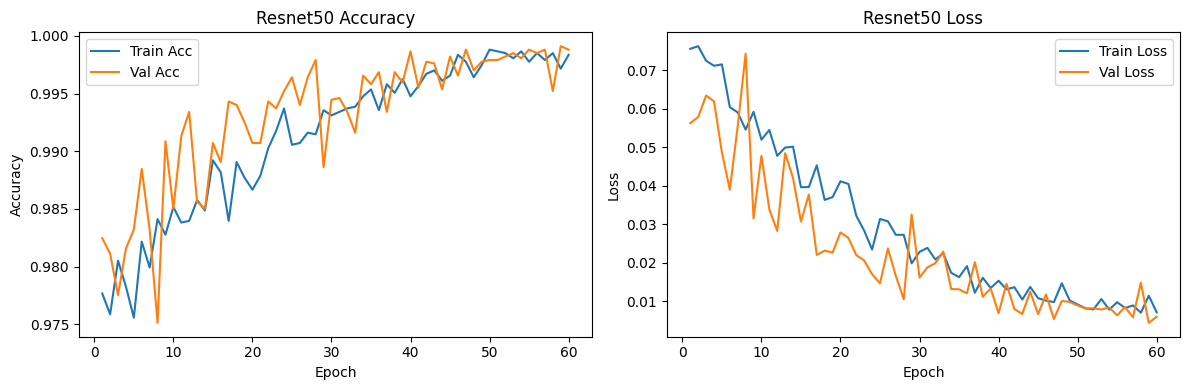

In [29]:
plot_training_history(history_Resnet50, model_name='Resnet50')

### ResNet50 Learning Curve Interpretation

The ResNet50 model demonstrates stable and consistent training. Both training and validation accuracy improve together, with validation accuracy tracking very closely throughout. The loss curves also show steady decline for both training and validation without significant divergence. This indicates strong generalization and no overfitting, making full training over all epochs effective for this model.

### (IMPLEMENTATION) Load the Model with the Best Validation Loss

In [30]:
### Load the model weights with the best validation loss.
Resnet50_model = load_model('saved_models/weights.best.Resnet50.hdf5')

### (IMPLEMENTATION) Test the Model

Try out your model on the test dataset of dog images. Ensure that your test accuracy is greater than 60%.

In [31]:
### Calculate classification accuracy on the test dataset.
# Test the model
test_predictions = Resnet50_model.predict(test_Resnet50, batch_size=20)
test_accuracy = 100 * np.mean(np.argmax(test_predictions, axis=1) == np.argmax(resnet50_test_y, axis=1))
print('Test accuracy: %.4f%%' % test_accuracy)

42/42 [==============================] - 0s 10ms/step
Test accuracy: 76.8862%


# Model InceptionV3

In [32]:
clear_graph()

In [10]:
# Load bottleneck features and targets for InceptionV3
train_Inception , valid_Inception, test_Inception, inception_train_y, inception_valid_y, inception_test_y = \
    load_bottleneck_and_targets('InceptionV3')

In [35]:
InceptionV3_model = Sequential()
InceptionV3_model.add(GlobalAveragePooling2D(input_shape=train_Inception.shape[1:]))
InceptionV3_model.add(Dense(133, activation='softmax'))

InceptionV3_model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

model_name = 'InceptionV3'
save_bottleneck_to_h5(train_Inception, inception_train_y, f'{model_name}_bottlenecks_train.h5')
save_bottleneck_to_h5(valid_Inception, inception_valid_y, f'{model_name}_bottlenecks_valid.h5')

history_inception = train_model_with_h5sequence(
    model=InceptionV3_model,
    train_h5=f'{model_name}_bottlenecks_train.h5',
    valid_h5=f'{model_name}_bottlenecks_valid.h5',
    batch_size=8,
    epochs=60,
    model_name=model_name
)

File already exists, skipping: InceptionV3_bottlenecks_train.h5
File already exists, skipping: InceptionV3_bottlenecks_valid.h5
Epoch 1/60
835/835 [==============================] - ETA: 0s - loss: 3.0634 - accuracy: 0.4354
Epoch 1: val_loss improved from inf to 1.34660, saving model to saved_models/weights.best.InceptionV3.hdf5
835/835 [==============================] - 22s 26ms/step - loss: 3.0634 - accuracy: 0.4354 - val_loss: 1.3466 - val_accuracy: 0.6407
Epoch 2/60
834/835 [============================>.] - ETA: 0s - loss: 1.2967 - accuracy: 0.6508
Epoch 2: val_loss improved from 1.34660 to 1.18579, saving model to saved_models/weights.best.InceptionV3.hdf5
835/835 [==============================] - 19s 23ms/step - loss: 1.2982 - accuracy: 0.6500 - val_loss: 1.1858 - val_accuracy: 0.7030
Epoch 3/60
834/835 [============================>.] - ETA: 0s - loss: 1.0446 - accuracy: 0.7155
Epoch 3: val_loss improved from 1.18579 to 1.12164, saving model to saved_models/weights.best.Incept

835/835 [==============================] - 13s 15ms/step - loss: 0.2408 - accuracy: 0.9228 - val_loss: 0.9257 - val_accuracy: 0.8132
Epoch 29/60
835/835 [==============================] - ETA: 0s - loss: 0.2587 - accuracy: 0.9219
Epoch 29: val_loss did not improve from 0.77978
835/835 [==============================] - 13s 16ms/step - loss: 0.2587 - accuracy: 0.9219 - val_loss: 0.8799 - val_accuracy: 0.8156
Epoch 30/60
834/835 [============================>.] - ETA: 0s - loss: 0.2414 - accuracy: 0.9240
Epoch 30: val_loss did not improve from 0.77978
835/835 [==============================] - 14s 16ms/step - loss: 0.2412 - accuracy: 0.9240 - val_loss: 0.8648 - val_accuracy: 0.8132
Epoch 31/60
833/835 [============================>.] - ETA: 0s - loss: 0.2320 - accuracy: 0.9257
Epoch 31: val_loss did not improve from 0.77978
835/835 [==============================] - 14s 17ms/step - loss: 0.2314 - accuracy: 0.9258 - val_loss: 0.8620 - val_accuracy: 0.8251
Epoch 32/60
833/835 [============

Epoch 58/60
833/835 [============================>.] - ETA: 0s - loss: 0.1081 - accuracy: 0.9667
Epoch 58: val_loss did not improve from 0.77978
835/835 [==============================] - 21s 25ms/step - loss: 0.1079 - accuracy: 0.9667 - val_loss: 0.9139 - val_accuracy: 0.8192
Epoch 59/60
834/835 [============================>.] - ETA: 0s - loss: 0.0891 - accuracy: 0.9682
Epoch 59: val_loss did not improve from 0.77978
835/835 [==============================] - 19s 23ms/step - loss: 0.0890 - accuracy: 0.9682 - val_loss: 0.9745 - val_accuracy: 0.8156
Epoch 60/60
834/835 [============================>.] - ETA: 0s - loss: 0.0952 - accuracy: 0.9667
Epoch 60: val_loss did not improve from 0.77978
835/835 [==============================] - 32s 38ms/step - loss: 0.0950 - accuracy: 0.9667 - val_loss: 0.9506 - val_accuracy: 0.8132


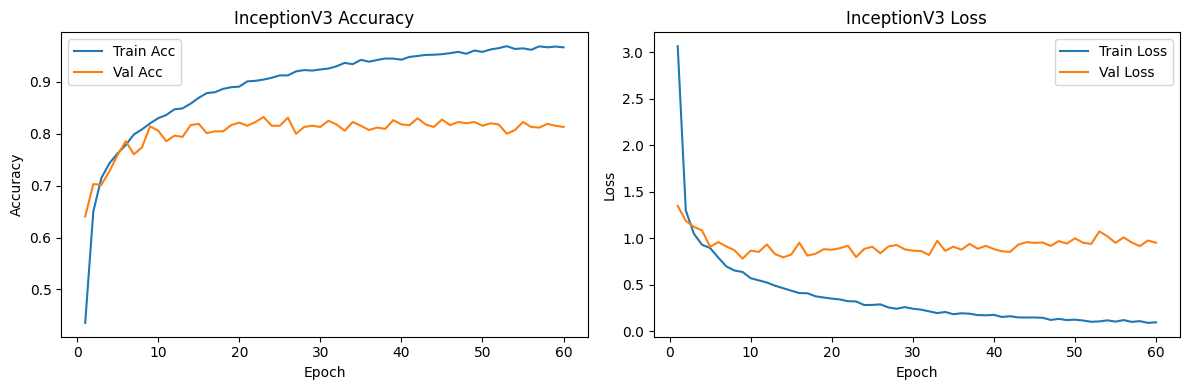

In [36]:
plot_training_history(history_inception, model_name='InceptionV3')

### InceptionV3 Learning Curve Interpretation

The InceptionV3 model shows a clear sign of overfitting. While training accuracy continues to improve across epochs, validation accuracy plateaus around epoch 15 and fluctuates thereafter. Similarly, validation loss stops decreasing and begins to oscillate, whereas training loss steadily declines. This suggests the model fits the training data well but fails to improve generalization beyond a certain point. In ResNet50 model, such overfitting is not observed, indicating that applying early stopping around the plateau point would be beneficial here.


In [11]:
InceptionV3_model = Sequential()
InceptionV3_model.add(GlobalAveragePooling2D(input_shape=train_Inception.shape[1:]))
InceptionV3_model.add(Dense(133, activation='softmax'))
# Load the model weights with the best validation loss.
InceptionV3_model.load_weights('saved_models/weights.best.InceptionV3.hdf5')

In [12]:
# Predict and evaluate
test_predictions = InceptionV3_model.predict(test_Inception, batch_size=20)
test_accuracy = 100 * np.mean(np.argmax(test_predictions, axis=1) == np.argmax(inception_test_y, axis=1))
print('InceptionV3 Test accuracy: %.4f%%' % test_accuracy)

42/42 [==============================] - 0s 4ms/step
InceptionV3 Test accuracy: 77.3653%


# Model Xception

In [14]:
clear_graph()

In [15]:
# Load bottleneck features and targets for Xception
train_Xception , valid_Xception, test_Xception, xception_train_y, xception_valid_y, xception_test_y = \
    load_bottleneck_and_targets('Xception')

In [16]:
Xception_model = Sequential()
Xception_model.add(GlobalAveragePooling2D(input_shape=train_Xception.shape[1:]))
Xception_model.add(Dense(133, activation='softmax'))

Xception_model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

model_name = 'Xception'
save_bottleneck_to_h5(train_Xception, xception_train_y, f'{model_name}_bottlenecks_train.h5')
save_bottleneck_to_h5(valid_Xception, xception_valid_y, f'{model_name}_bottlenecks_valid.h5')

history_xception = train_model_with_h5sequence(
    model=Xception_model,
    train_h5=f'{model_name}_bottlenecks_train.h5',
    valid_h5=f'{model_name}_bottlenecks_valid.h5',
    batch_size=8,
    epochs=60,
    model_name=model_name
)

File already exists, skipping: Xception_bottlenecks_train.h5
File already exists, skipping: Xception_bottlenecks_valid.h5
Epoch 1/60


2025-04-30 20:04:43.756840: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0xa4ed320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-30 20:04:43.756907: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2025-04-30 20:04:43.763500: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-30 20:04:43.783728: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2025-04-30 20:04:43.906270: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


835/835 [==============================] - ETA: 0s - loss: 2.7392 - accuracy: 0.4049
Epoch 1: val_loss improved from inf to 1.07395, saving model to saved_models/weights.best.Xception.hdf5
835/835 [==============================] - 43s 51ms/step - loss: 2.7392 - accuracy: 0.4049 - val_loss: 1.0740 - val_accuracy: 0.6551
Epoch 2/60
 11/835 [..............................] - ETA: 8s - loss: 1.2830 - accuracy: 0.6023

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


829/835 [============================>.] - ETA: 0s - loss: 1.0751 - accuracy: 0.6670
Epoch 2: val_loss improved from 1.07395 to 0.87815, saving model to saved_models/weights.best.Xception.hdf5
835/835 [==============================] - 10s 12ms/step - loss: 1.0765 - accuracy: 0.6665 - val_loss: 0.8781 - val_accuracy: 0.7162
Epoch 3/60
826/835 [============================>.] - ETA: 0s - loss: 0.8553 - accuracy: 0.7188
Epoch 3: val_loss improved from 0.87815 to 0.87559, saving model to saved_models/weights.best.Xception.hdf5
835/835 [==============================] - 10s 11ms/step - loss: 0.8504 - accuracy: 0.7204 - val_loss: 0.8756 - val_accuracy: 0.7234
Epoch 4/60
834/835 [============================>.] - ETA: 0s - loss: 0.7521 - accuracy: 0.7540
Epoch 4: val_loss improved from 0.87559 to 0.76632, saving model to saved_models/weights.best.Xception.hdf5
835/835 [==============================] - 10s 12ms/step - loss: 0.7519 - accuracy: 0.7540 - val_loss: 0.7663 - val_accuracy: 0.7569


Epoch 30/60
835/835 [==============================] - ETA: 0s - loss: 0.2729 - accuracy: 0.9101
Epoch 30: val_loss did not improve from 0.64044
835/835 [==============================] - 24s 29ms/step - loss: 0.2729 - accuracy: 0.9101 - val_loss: 0.7680 - val_accuracy: 0.7940
Epoch 31/60
835/835 [==============================] - ETA: 0s - loss: 0.2758 - accuracy: 0.9109
Epoch 31: val_loss did not improve from 0.64044
835/835 [==============================] - 26s 32ms/step - loss: 0.2758 - accuracy: 0.9109 - val_loss: 0.7294 - val_accuracy: 0.8060
Epoch 32/60
831/835 [============================>.] - ETA: 0s - loss: 0.2619 - accuracy: 0.9183
Epoch 32: val_loss did not improve from 0.64044
835/835 [==============================] - 25s 30ms/step - loss: 0.2608 - accuracy: 0.9187 - val_loss: 0.7670 - val_accuracy: 0.7952
Epoch 33/60
834/835 [============================>.] - ETA: 0s - loss: 0.2562 - accuracy: 0.9163
Epoch 33: val_loss did not improve from 0.64044
835/835 [============

835/835 [==============================] - 24s 29ms/step - loss: 0.1550 - accuracy: 0.9500 - val_loss: 0.8102 - val_accuracy: 0.7916
Epoch 60/60
834/835 [============================>.] - ETA: 0s - loss: 0.1575 - accuracy: 0.9486
Epoch 60: val_loss did not improve from 0.64044
835/835 [==============================] - 22s 26ms/step - loss: 0.1574 - accuracy: 0.9486 - val_loss: 0.7995 - val_accuracy: 0.7964


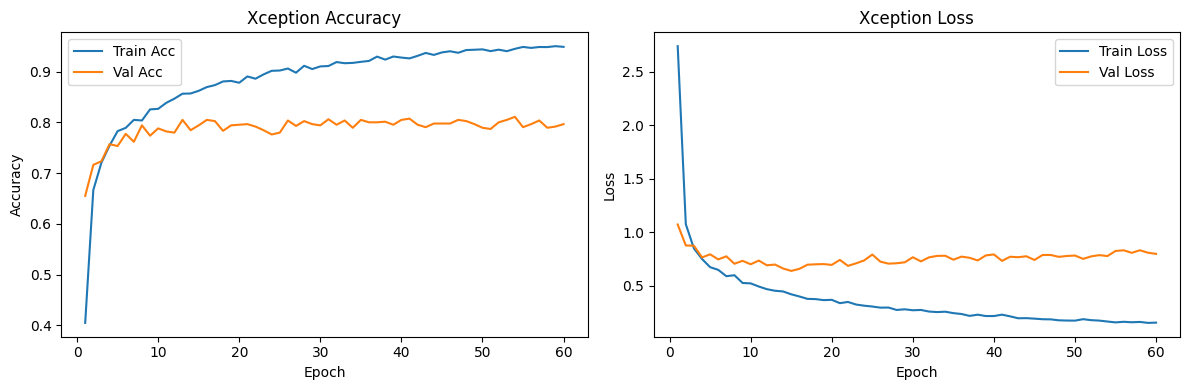

In [17]:
plot_training_history(history_xception, model_name='Xception')

### Xception Learning Curve Interpretation

The Xception model shows a classic overfitting pattern. Training accuracy continues to rise steadily throughout training, reaching above 95%, while validation accuracy improves quickly in the early epochs but then plateaus around 80% and remains flat. On the loss plot, training loss steadily decreases, but validation loss flattens and begins to slightly increase after epoch 15–20. This indicates that the model continues to fit the training data better over time but does not generalize further to unseen data. Early stopping based on validation accuracy or loss with a higher patience value would help terminate training at the optimal point before overfitting intensifies, similar to what was observed with the InceptionV3 model.


In [18]:
Xception_model.load_weights('saved_models/weights.best.Xception.hdf5')

test_predictions = Xception_model.predict(test_Xception, batch_size=20)
test_accuracy = 100 * np.mean(np.argmax(test_predictions, axis=1) == np.argmax(xception_test_y, axis=1))
print('Xception Test accuracy: %.4f%%' % test_accuracy)

42/42 [==============================] - 1s 8ms/step
Xception Test accuracy: 81.5569%


# Model VGG19

In [19]:
clear_graph()

In [20]:
# Load bottleneck features and targets for VGG19
train_VGG19 , valid_VGG19, test_VGG19, vgg19_train_y, vgg19_valid_y, vgg19_test_y = \
    load_bottleneck_and_targets('VGG19')

In [21]:
VGG19_model = Sequential()
VGG19_model.add(GlobalAveragePooling2D(input_shape=train_VGG19.shape[1:]))
VGG19_model.add(Dense(133, activation='softmax'))

VGG19_model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

model_name = 'VGG19'
save_bottleneck_to_h5(train_VGG19, vgg19_train_y, f'{model_name}_bottlenecks_train.h5')
save_bottleneck_to_h5(valid_VGG19, vgg19_valid_y, f'{model_name}_bottlenecks_valid.h5')

history_vgg19 = train_model_with_h5sequence(
    model=VGG19_model,
    train_h5=f'{model_name}_bottlenecks_train.h5',
    valid_h5=f'{model_name}_bottlenecks_valid.h5',
    batch_size=8,
    epochs=60,
    model_name=model_name
)

File already exists, skipping: VGG19_bottlenecks_train.h5
File already exists, skipping: VGG19_bottlenecks_valid.h5
Epoch 1/60
830/835 [============================>.] - ETA: 0s - loss: 13.5682 - accuracy: 0.0622
Epoch 1: val_loss improved from inf to 7.80038, saving model to saved_models/weights.best.VGG19.hdf5
835/835 [==============================] - 10s 11ms/step - loss: 13.5416 - accuracy: 0.0623 - val_loss: 7.8004 - val_accuracy: 0.2024
Epoch 2/60
833/835 [============================>.] - ETA: 0s - loss: 6.0814 - accuracy: 0.2783
Epoch 2: val_loss improved from 7.80038 to 5.19722, saving model to saved_models/weights.best.VGG19.hdf5
835/835 [==============================] - 7s 8ms/step - loss: 6.0733 - accuracy: 0.2787 - val_loss: 5.1972 - val_accuracy: 0.3341
Epoch 3/60
831/835 [============================>.] - ETA: 0s - loss: 4.0869 - accuracy: 0.4150
Epoch 3: val_loss improved from 5.19722 to 3.96883, saving model to saved_models/weights.best.VGG19.hdf5
835/835 [==========

835/835 [==============================] - 6s 7ms/step - loss: 0.4599 - accuracy: 0.8879 - val_loss: 2.4137 - val_accuracy: 0.6323
Epoch 29/60
834/835 [============================>.] - ETA: 0s - loss: 0.4941 - accuracy: 0.8853
Epoch 29: val_loss did not improve from 2.36621
835/835 [==============================] - 8s 9ms/step - loss: 0.4950 - accuracy: 0.8846 - val_loss: 2.7293 - val_accuracy: 0.6299
Epoch 30/60
830/835 [============================>.] - ETA: 0s - loss: 0.4697 - accuracy: 0.8903
Epoch 30: val_loss did not improve from 2.36621
835/835 [==============================] - 7s 9ms/step - loss: 0.4681 - accuracy: 0.8905 - val_loss: 2.5529 - val_accuracy: 0.6575
Epoch 31/60
834/835 [============================>.] - ETA: 0s - loss: 0.4651 - accuracy: 0.8893
Epoch 31: val_loss did not improve from 2.36621
835/835 [==============================] - 7s 8ms/step - loss: 0.4646 - accuracy: 0.8894 - val_loss: 2.4933 - val_accuracy: 0.6455
Epoch 32/60
830/835 [====================

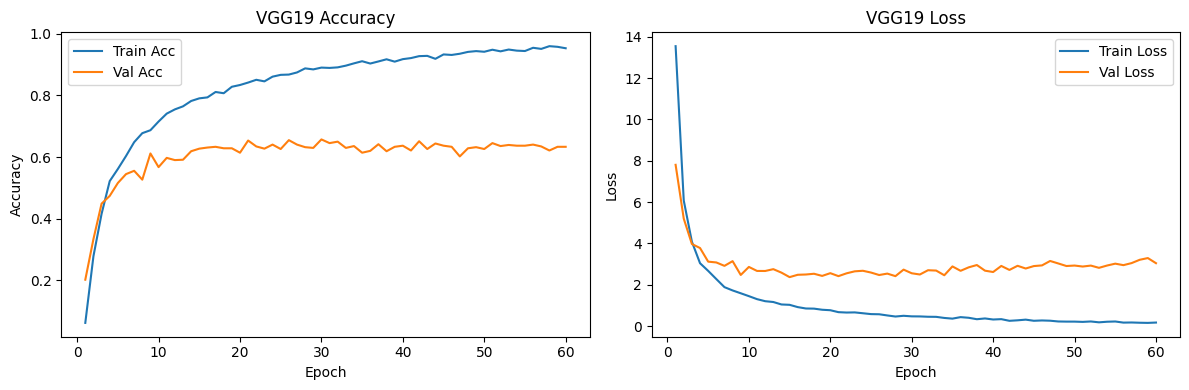

In [22]:
plot_training_history(history_vgg19, model_name='VGG19')

### VGG19 Learning Curve Interpretation

The VGG19 model shows clear overfitting. Training accuracy continues to rise while validation accuracy plateaus early around 65%. Similarly, training loss decreases steadily, but validation loss flattens and then slowly increases. This pattern, also seen in earlier models like InceptionV3 and Xception, indicates that the model learns the training data well but fails to improve on unseen data. Early stopping would help avoid unnecessary overtraining.

In [23]:
VGG19_model.load_weights('saved_models/weights.best.VGG19.hdf5')

test_predictions = VGG19_model.predict(test_VGG19, batch_size=20)
test_accuracy = 100 * np.mean(np.argmax(test_predictions, axis=1) == np.argmax(vgg19_test_y, axis=1))
print('VGG19 Test accuracy: %.4f%%' % test_accuracy)### VGG19 Learning Curve Interpretation

The VGG19 model shows clear overfitting. Training accuracy continues to rise while validation accuracy plateaus early around 65%. Similarly, training loss decreases steadily, but validation loss flattens and then slowly increases. This pattern, also seen in earlier models like InceptionV3 and Xception, indicates that the model learns the training data
### VGG19 Learning Curve Interpretation

The VGG19 model shows clear overfitting. Training accuracy continues to rise while validation accuracy plateaus early around 65%. Similarly, training loss decreases steadily, but validation loss flattens and then slowly increases. This pattern, also seen in earlier models like InceptionV3 and Xception, indicates that the model learns the training data well but fails to improve on unseen data. Early stopping would help avoid unnecessary overtraining.


42/42 [==============================] - 0s 4ms/step
VGG19 Test accuracy: 63.1138%


# Augmentation

In [24]:
clear_graph()

In [2]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import RMSprop
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze base

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(133, activation='softmax')
])

model.compile(optimizer=RMSprop(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


2025-04-30 21:40:55.328312: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-30 21:40:55.332998: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-30 21:40:55.336192: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

83683744/83683744 [==============================] - 0s 0us/step


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)

In [4]:
train_dir = '/workspace/home/dog-project/dog_images/train'
valid_dir = '/workspace/home/dog-project/dog_images/valid'

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical'
)

Found 6675 images belonging to 133 classes.
Found 835 images belonging to 133 classes.


In [5]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpointer = ModelCheckpoint(
    filepath='saved_models/weights.best.Xception.augmented.hdf5',
    verbose=1,
    save_best_only=True
)

earlystopper = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_xception_aug = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=50,
    callbacks=[checkpointer, earlystopper],
    verbose=1
)

Epoch 1/50


2025-04-30 21:41:24.930438: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2025-04-30 21:41:27.612304: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7cc52685e1d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-30 21:41:27.612380: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2025-04-30 21:41:27.617638: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-30 21:41:27.718779: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


835/835 [==============================] - ETA: 0s - loss: 3.2918 - accuracy: 0.3431
Epoch 1: val_loss improved from inf to 1.60367, saving model to saved_models/weights.best.Xception.augmented.hdf5


/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


835/835 [==============================] - 250s 293ms/step - loss: 3.2918 - accuracy: 0.3431 - val_loss: 1.6037 - val_accuracy: 0.6671
Epoch 2/50
835/835 [==============================] - ETA: 0s - loss: 1.4415 - accuracy: 0.6451
Epoch 2: val_loss improved from 1.60367 to 0.93320, saving model to saved_models/weights.best.Xception.augmented.hdf5
835/835 [==============================] - 128s 154ms/step - loss: 1.4415 - accuracy: 0.6451 - val_loss: 0.9332 - val_accuracy: 0.7437
Epoch 3/50
835/835 [==============================] - ETA: 0s - loss: 1.0483 - accuracy: 0.6999
Epoch 3: val_loss improved from 0.93320 to 0.75490, saving model to saved_models/weights.best.Xception.augmented.hdf5
835/835 [==============================] - 109s 130ms/step - loss: 1.0483 - accuracy: 0.6999 - val_loss: 0.7549 - val_accuracy: 0.7760
Epoch 4/50
835/835 [==============================] - ETA: 0s - loss: 0.9108 - accuracy: 0.7336
Epoch 4: val_loss improved from 0.75490 to 0.67565, saving model to sav

835/835 [==============================] - 108s 130ms/step - loss: 0.6213 - accuracy: 0.8211 - val_loss: 0.4916 - val_accuracy: 0.8347
Epoch 26/50
835/835 [==============================] - ETA: 0s - loss: 0.6220 - accuracy: 0.8171
Epoch 26: val_loss did not improve from 0.49164
835/835 [==============================] - 104s 125ms/step - loss: 0.6220 - accuracy: 0.8171 - val_loss: 0.4918 - val_accuracy: 0.8359
Epoch 27/50
835/835 [==============================] - ETA: 0s - loss: 0.6135 - accuracy: 0.8174
Epoch 27: val_loss improved from 0.49164 to 0.49083, saving model to saved_models/weights.best.Xception.augmented.hdf5
835/835 [==============================] - 107s 128ms/step - loss: 0.6135 - accuracy: 0.8174 - val_loss: 0.4908 - val_accuracy: 0.8395
Epoch 28/50
835/835 [==============================] - ETA: 0s - loss: 0.6109 - accuracy: 0.8159
Epoch 28: val_loss did not improve from 0.49083
835/835 [==============================] - 106s 127ms/step - loss: 0.6109 - accuracy: 0.8

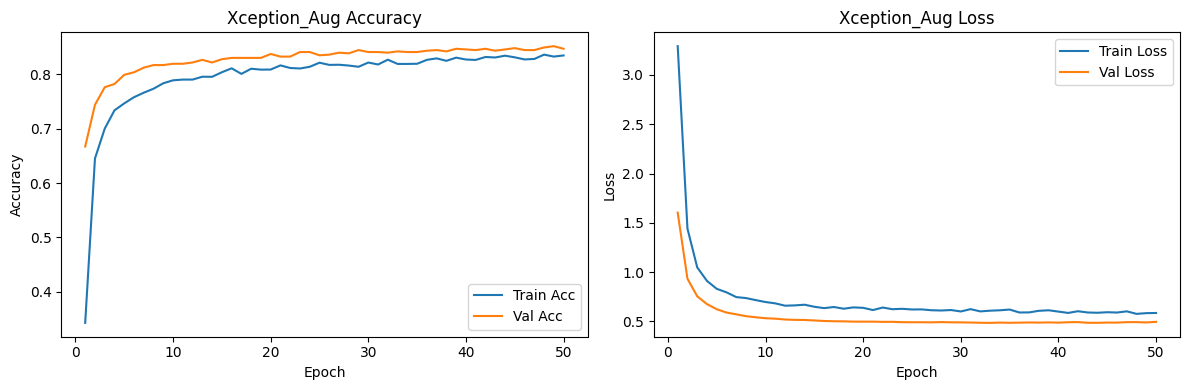

In [9]:
plot_training_history(history_xception_aug, model_name='Xception_Aug')

In [15]:
import numpy as np
model.load_weights('saved_models/weights.best.Xception.augmented.hdf5')

# 3. Create test generator
test_dir = '/workspace/home/dog-project/dog_images/test'

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 4. Evaluate
predictions = model.predict(test_generator)
test_accuracy = 100 * np.mean(np.argmax(predictions, axis=1) == test_generator.classes)

print('Xception (augmented) Test accuracy: %.4f%%' % test_accuracy)

Found 835 images belonging to 133 classes.
27/27 [==============================] - 6s 207ms/step
Xception (augmented) Test accuracy: 84.9102%


### Final Test Accuracy Results for All Models

| Model                   | Test Accuracy |
|------------------------|----------------|
| Custom CNN (from scratch) | **5.77%**       |
| VGG16                  | 69.46%         |
| VGG19                  | 63.11%         |
| ResNet50               | 76.89%         |
| InceptionV3            | 77.37%         |
| Xception               | 81.56%         |
| Xception (augmented)   | **84.91%**     |

#### 📝 Observations

- The **custom model trained from scratch** performed poorly (5.77%), confirming that a simple CNN lacks the capacity to learn this complex task without transfer learning or data augmentation.
- All **pretrained models** significantly outperform the custom model, benefiting from prior learning on ImageNet.
- Among the non-augmented models, **Xception** achieves the highest accuracy (81.56%), followed closely by InceptionV3 and ResNet50.
- The **Xception model trained with image augmentation** yields the **best overall performance (84.91%)**, demonstrating that data augmentation helps improve generalization by exposing the model to more varied training examples.

These results highlight the strength of transfer learning and show that both model architecture and data strategy (e.g., augmentation) play a crucial role in improving classification performance.

### (IMPLEMENTATION) Predict Dog Breed with the Model

Write a function that takes an image path as input and returns the dog breed (`Affenpinscher`, `Afghan_hound`, etc) that is predicted by your model.  

Similar to the analogous function in Step 5, your function should have three steps:
1. Extract the bottleneck features corresponding to the chosen CNN model.
2. Supply the bottleneck features as input to the model to return the predicted vector.  Note that the argmax of this prediction vector gives the index of the predicted dog breed.
3. Use the `dog_names` array defined in Step 0 of this notebook to return the corresponding breed.

The functions to extract the bottleneck features can be found in `extract_bottleneck_features.py`, and they have been imported in an earlier code cell.  To obtain the bottleneck features corresponding to your chosen CNN architecture, you need to use the function

    extract_{network}
    
where `{network}`, in the above filename, should be one of `VGG19`, `Resnet50`, `InceptionV3`, or `Xception`.

In [38]:
### Function that takes a path to an image as input
### and returns the dog breed that is predicted by the model.
from extract_bottleneck_features import extract_Xception
from tensorflow.keras.models import load_model
import numpy as np       

def Xception_predict_breed(img_path):
    # extract bottleneck features
    bottleneck_feature = extract_Xception(path_to_tensor(img_path))
    #load desired model --Xception
    Xception_model = load_model('saved_models/weights.best.Xception.hdf5')
    # obtain predicted vector
    predicted_vector = Xception_model.predict(bottleneck_feature)
    # return dog breed that is predicted by the model
    breed_path = dog_names[np.argmax(predicted_vector)]

    return breed_path

1/1 [==============================] - 0s 50ms/step


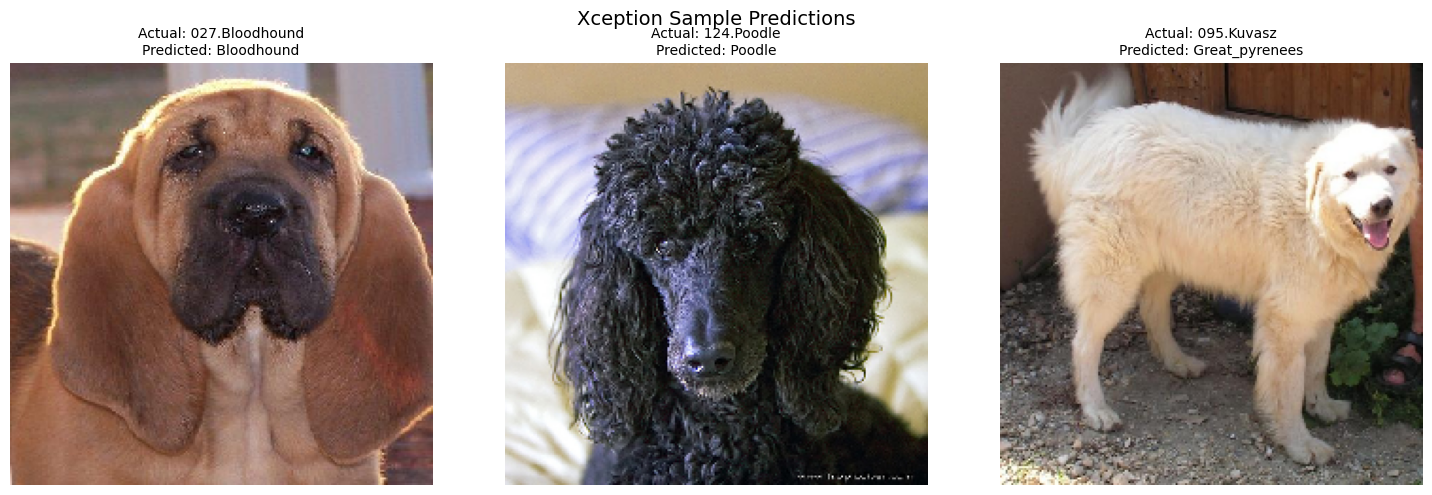

In [39]:
show_sample_predictions_from_test(
    test_dir='/workspace/home/dog-project/dog_images/test',
    predict_func=Xception_predict_breed,
    model_name='Xception',
    sample_size=3
)

### Note on Prediction Methods

The standard prediction function uses precomputed bottleneck features (e.g., `extract_Xception`) as input to a lightweight classifier trained on those features. In contrast, the augmented Xception model is trained end-to-end on raw images with real-time data augmentation. Therefore, its prediction function directly processes the image input rather than using precomputed features. We have some additional functions below to make predictions with augmented model.

In [19]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

def load_augmented_xception_model():
    base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # optional: keep frozen if matching original training

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(133, activation='softmax')
    ])

    model.load_weights('saved_models/weights.best.Xception.augmented.hdf5')
    return model

In [28]:
from tensorflow.keras.preprocessing import image
import numpy as np

def Xception_augmented_predict_breed(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_tensor = image.img_to_array(img)
    img_tensor = np.expand_dims(img_tensor, axis=0)
    img_tensor /= 255.

    predicted_vector = model.predict(img_tensor)
    breed_path = dog_names[np.argmax(predicted_vector)]
    return breed_path  # single string, consistent with previous usage

1/1 [==============================] - 0s 31ms/step


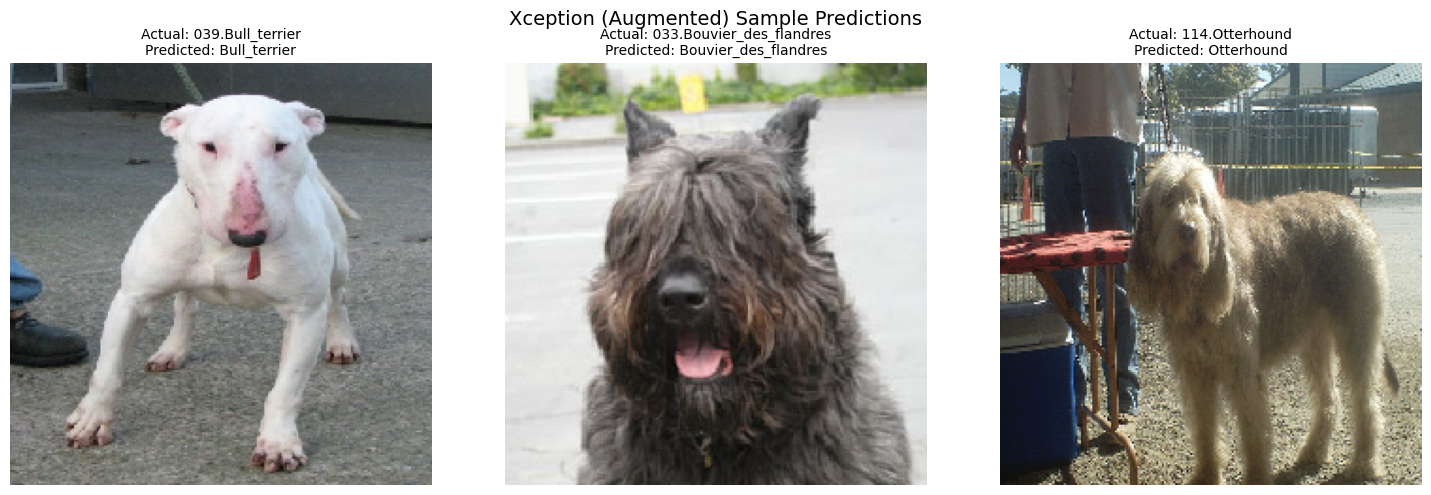

In [29]:
from functools import partial

# Load the model once
xception_aug_model = load_augmented_xception_model()

# Create a wrapped function that only passes img_path and model
predict_func = lambda img_path: Xception_augmented_predict_breed(img_path, model=xception_aug_model)

# Use in your visualization
show_sample_predictions_from_test(
    test_dir='/workspace/home/dog-project/dog_images/test',
    predict_func=predict_func,
    model_name='Xception (Augmented)',
    sample_size=3
)

---
<a id='step6'></a>
## Step 6: Write your Algorithm

Write an algorithm that accepts a file path to an image and first determines whether the image contains a human, dog, or neither.  Then,
- if a __dog__ is detected in the image, return the predicted breed.
- if a __human__ is detected in the image, return the resembling dog breed.
- if __neither__ is detected in the image, provide output that indicates an error.

You are welcome to write your own functions for detecting humans and dogs in images, but feel free to use the `face_detector` and `dog_detector` functions developed above.  You are __required__ to use your CNN from Step 5 to predict dog breed.  

A sample image and output for our algorithm is provided below, but feel free to design your own user experience!

![Sample Human Output](images/sample_human_2.png)

This photo looks like an Afghan Hound.
### (IMPLEMENTATION) Write your Algorithm

In [3]:
from tensorflow.keras.models import load_model

# Load the saved model
Resnet50_model = load_model('saved_models/weights.best.Resnet50.h5')

# Check the model summary to verify
Resnet50_model.summary()

2025-01-02 05:10:02.030640: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-02 05:10:02.042344: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-02 05:10:02.045774: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 batch_normalization (Batch  (None, 2048)              8192      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 133)               272517    
                                                                 
Total params: 280709 (1.07 MB)
Trainable params: 276613 (1.06 MB)
Non-trainable params: 4096 (16.00 KB)
_________________________________________________________________


2025-01-02 05:10:02.051459: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-02 05:10:02.054944: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-02 05:10:02.058154: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [1]:
import cv2
from keras.preprocessing import image                  
from tqdm import tqdm
from keras.applications.resnet50 import preprocess_input, decode_predictions
from keras.applications.resnet50 import ResNet50

def preprocess_image(img_path, target_size=(224, 224)):
    """
    Preprocess the image for the CNN model.
    - Resizes image to the target size.
    - Scales pixel values to [0, 1].
    """
    try:
        img = image.load_img(img_path, target_size=target_size)  # Load and resize image
        img_array = image.img_to_array(img)  # Convert to numpy array
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
        return img_array
    except IOError:
        print(f"Warning: Skipping corrupted image {img_path}")
        return None        

def paths_to_tensor(img_paths):
    batch_tensors = []
    for img_path in img_paths:
        tensor = preprocess_image(img_path)
        if tensor is not None:
            batch_tensors.append(tensor[0])
    return np.array(batch_tensors)


face_cascade = cv2.CascadeClassifier('haarcascades/haarcascade_frontalface_alt.xml')
def face_detector(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray)
    return len(faces) > 0

# define ResNet50 model
ResNet50_dm = ResNet50(weights='imagenet')

def ResNet50_predict_labels(img_path):
    # returns prediction vector for image located at img_path
    img = preprocess_input(preprocess_image(img_path))
    return np.argmax(ResNet50_dm.predict(img))

### returns "True" if a dog is detected in the image stored at img_path
def dog_detector(img_path):
    prediction = ResNet50_predict_labels(img_path)
    return ((prediction <= 268) & (prediction >= 151)) 

2025-05-01 00:06:27.949579: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-01 00:06:27.949635: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-01 00:06:27.949740: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-01 00:06:27.963200: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-01 00:06:30.684047: I tensorflow/compiler/

102967424/102967424 [==============================] - 0s 0us/step


In [26]:
# from extract_bottleneck_features import *
# import tensorflow as tf 
# from tensorflow.keras.models import load_model


# def Resnet50_predict_breed(img_path):
#     # extract bottleneck features
#     bottleneck_feature = extract_Resnet50(preprocess_image(img_path))
# #     bottleneck_feature = tf.keras.layers.GlobalAveragePooling2D()(bottleneck_feature)
# #     bottleneck_feature = np.expand_dims(bottleneck_feature, axis=(1, 2)) 
    
#     #load desired model --ResNet50
#     Resnet50_model = load_model('saved_models/weights.best.Resnet50.hdf5')        
#     # obtain predicted vector
#     predicted_vector = Resnet50_model.predict(bottleneck_feature)
    
#     # return dog breed that is predicted by the model
#     breed_path = dog_names[np.argmax(predicted_vector)]
#     breed_file = breed_path.split("/")[-1]
#     breed = breed_path.split(".")[-1]
#     return breed, breed_file

In [2]:
from extract_bottleneck_features import extract_Xception        
from tensorflow.keras.models import load_model
import numpy as np                                              

def Xception_predict_breed(img_path):

    # Extract Xception bottleneck features for this one image
    bottleneck_feature = extract_Xception(preprocess_image(img_path))   # shape (1, 10,10,2048)

    # Load the fine-tuned classification head trained on those features
    xception_model = load_model('saved_models/weights.best.Xception.hdf5')

    # Predict breed probabilities
    predicted_vector = xception_model.predict(bottleneck_feature)

    # Map the top-probability index → breed name
    breed_path  = dog_names[np.argmax(predicted_vector)]     
    breed_file  = breed_path.split('/')[-1]                  
    breed       = breed_path.split('.')[-1]                  
    return breed, breed_file


In [12]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt                        
%matplotlib inline        
import glob
import os

def display_images(img_path, breed, breed_file, num_samples=3):
    """
    Plots the input image and sample images for the predicted breed.
    - img_path: Path to the input image.
    - breed: Predicted breed name.
    - breed_image_paths: Dictionary mapping breed names to lists of image paths.
    - num_samples: Number of sample images to display for the breed.
    """
    # Load the input image
    input_image = mpimg.imread(img_path)

    # Fetch all matching breed images using glob
    base_path = "dog_images/train/"
    breed_image_path = f"{os.path.join(base_path, breed_file)}/*"
    breed_sample_paths = glob.glob(breed_image_path)

    # Randomly select images from the breed folder
    selected_samples = random.sample(breed_sample_paths, min(num_samples, len(breed_sample_paths)))

    # Plot input image and breed samples
    plt.figure(figsize=(15, 5))

    # Plot the input image
    plt.subplot(1, num_samples + 1, 1)
    plt.imshow(input_image)
    plt.title("Input Image")
    plt.axis("off")

    # Plot sample images for the breed
    for i, sample_path in enumerate(selected_samples):
        sample_image = mpimg.imread(sample_path)
        plt.subplot(1, num_samples + 1, i + 2)
        plt.imshow(sample_image)
        plt.title(f"Sample {i+1}")
        plt.axis("off")

    plt.show()

In [13]:
###  Algorithm that returns {'human' | 'dog' | 'neither'} 
def run_algorithm(img_path, breed_predictor):
    """
    The main algorithm to detect humans, dogs, or neither, and predict breed.
    - If dog detected: Return the predicted breed.
    - If human detected: Return resembling dog breed.
    - If neither detected: Return an error message.
    """
    # Detect human or dog in the image
    is_human = face_detector(img_path)  # Returns True if a human face is detected
    is_dog = dog_detector(img_path)  # Returns True if a dog is detected
    
    # Case 1: Dog is detected
    if is_dog:
        breed, breed_file = breed_predictor(img_path)
        print(f"Dog detected! The predicted breed is: {breed}")
        display_images(img_path, breed, breed_file)
        return breed

    # Case 2: Human is detected
    elif is_human:
        breed, breed_file = breed_predictor(img_path)
        print(f"Human detected! You resemble a {breed}.")
        display_images(img_path, breed, breed_file)
        return breed

    # Case 3: Neither dog nor human is detected
    else:
        print("Error: No dog or human detected in the image.")
        return None

In [8]:
human_files_short = human_files[:10]
dog_files_short = train_files[:10]

In [10]:
breed, breed_file = Xception_predict_breed(dog_files_short[0])
breed_file

2025-05-01 00:07:48.983441: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600


1/1 [==============================] - 0s 69ms/step


'024.Bichon_frise'

---
<a id='step7'></a>
## Step 7: Test Your Algorithm

In this section, you will take your new algorithm for a spin!  What kind of dog does the algorithm think that __you__ look like?  If you have a dog, does it predict your dog's breed accurately?  If you have a cat, does it mistakenly think that your cat is a dog?

### (IMPLEMENTATION) Test Your Algorithm on Sample Images!

Test your algorithm at least six images on your computer.  Feel free to use any images you like.  Use at least two human and two dog images.  

__Question 6:__ Is the output better than you expected :) ?  Or worse :( ?  Provide at least three possible points of improvement for your algorithm.

__Answer:__ 

1/1 [==============================] - 0s 48ms/step
Dog detected! The predicted breed is: Old_english_sheepdog


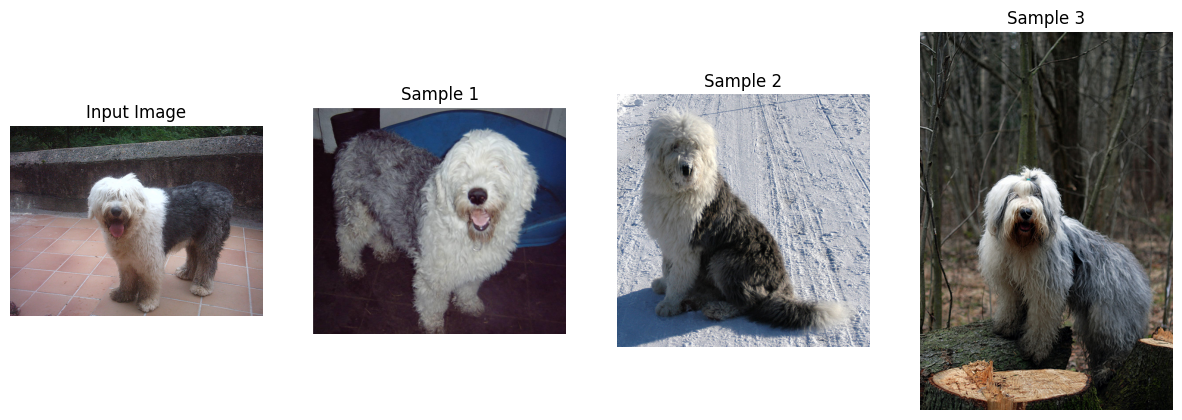

'Old_english_sheepdog'

In [14]:
## Execute your algorithm from Step 6 on
## at least 6 images on your computer.
## Feel free to use as many code cells as needed.

run_algorithm(dog_files_short[5], Xception_predict_breed)